# Chess ELO Prediction with Neural Networks

**Goal:** Given a completed chess game, predict both players' Elo ratings
from their playing style — not just the result.

The intuition is that *how* you play reveals your strength: strong players
manage the clock more carefully, avoid blunders, and control territory more
consistently than weaker players.

## Dataset
**Lichess open database, May 2017** — rated standard games.
Each game is a PGN string with move annotations and optional clock times.

## Four architectures compared on the same data

| Model | Sequence processing |
|---|---|
| **BiLSTM** | Two-layer bidirectional LSTM with soft attention |
| **Residual MLP** | No sequences — pure engineered features |
| **1D CNN** | Three parallel conv branches (kernels 3, 5, 7) |
| **Transformer** | Multi-head self-attention encoder |

Each model predicts a **probability distribution** over 40 Elo bins (0–4000),
trained with **KL divergence** against a Gaussian soft target.


In [246]:
import io, pickle, re, time, warnings, os
from copy import deepcopy
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import zstandard as zstd
import torch
import torch.nn as nn
from torch.nn.utils.rnn import pad_sequence
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

import chess_features_final as cff

warnings.filterwarnings('ignore')
plt.style.use('seaborn-v0_8-whitegrid')
print(f'PyTorch {torch.__version__}  |  CUDA: {torch.cuda.is_available()}')


PyTorch 2.5.1  |  CUDA: False


## Configuration

All experiment settings live here. Change `RUN_*` flags at the top to choose which models to train.


In [247]:
# ── Paths ─────────────────────────────────────────────────────────────────────
DATA_PATH = '../../data/elias_data/lichess_db_standard_rated_2017-05.pgn.zst'
CACHE_DIR = Path('cache');       CACHE_DIR.mkdir(exist_ok=True)
CKPT_DIR  = Path('checkpoints'); CKPT_DIR.mkdir(exist_ok=True)

# ── Dataset ────────────────────────────────────────────────────────────────────
MAX_GAMES   = 500_000
TIME_CONTROL = None   # e.g. "600+0" — exact match on TimeControl header (None = any)
TC_BASE_MIN  = 600   # minimum base time in seconds  (None = no bound)
TC_BASE_MAX  = 600   # maximum base time in seconds  (None = no bound)
TC_INC_MIN   = None   # minimum increment in seconds  (None = no bound)
TC_INC_MAX   = None   # maximum increment in seconds  (None = no bound)
SEED        = 42

# ── Which models to run (True / False) ────────────────────────────────────────
RUN_BILSTM      = True
RUN_RESIDUAL    = True
RUN_CNN         = True
RUN_TRANSFORMER = True

# ── Shared training settings ───────────────────────────────────────────────────
BATCH_SIZE   = 256
NUM_EPOCHS   = 10
LR           = 3e-4
WEIGHT_DECAY = 1e-4
DROPOUT      = 0.30
PATIENCE     = 3

# ── Elo bins ───────────────────────────────────────────────────────────────────
N_BINS    = 40      # 0 to 4000 in 100-pt steps
ELO_SIGMA = 200     # Gaussian spread for soft targets

# ── Sequence settings (BiLSTM, CNN, Transformer) ───────────────────────────────
MIN_PLIES   = 12
MAX_SEQ_LEN = 90
EMBED_DIM   = 64

# ── Model-specific dims ────────────────────────────────────────────────────────
BILSTM_HIDDEN   = 128
RESIDUAL_DIM    = 512
RESIDUAL_BLOCKS = 8
CNN_FILTERS     = 128
TRANS_DIM       = 128
TRANS_HEADS     = 4
TRANS_LAYERS    = 2
TRANS_FF_DIM    = 512

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
USE_AMP     = (device.type == 'cuda')
CPU_THREADS = os.cpu_count() or 4
torch.set_num_threads(CPU_THREADS)

BIN_EDGES   = np.linspace(0, 4000, N_BINS + 1)
BIN_CENTERS = ((BIN_EDGES[:-1] + BIN_EDGES[1:]) / 2).astype(np.float32)

# ── HPO settings ─────────────────────────────────────────────────────────────
# Set HPO_* = True to tune that model before full training (uses Optuna).
# Results are cached, so re-running is instant unless you delete the cache.
HPO_BILSTM      = False
HPO_RESIDUAL    = False
HPO_CNN         = False
HPO_TRANSFORMER = False

HPO_TRIALS = 10       # Optuna trials per model
HPO_GAMES  = 20_000   # games to train on per trial (keeps trials fast)
HPO_EPOCHS = 3        # training epochs per trial

print(f'Device : {device}')
print(f'Models : BiLSTM={RUN_BILSTM}  Residual={RUN_RESIDUAL}  CNN={RUN_CNN}  Transformer={RUN_TRANSFORMER}')
print(f'HPO    : BiLSTM={HPO_BILSTM}  Residual={HPO_RESIDUAL}  CNN={HPO_CNN}  Transformer={HPO_TRANSFORMER}')


Device : cpu
Models : BiLSTM=True  Residual=True  CNN=True  Transformer=True
HPO    : BiLSTM=False  Residual=False  CNN=False  Transformer=False


## 1 · Data Loading

Lichess publishes monthly PGN dumps compressed with zstandard (`.zst`).
We stream-parse the file game-by-game so we never decompress the entire file at once.

Each game becomes one row: header fields (White, Black, WhiteElo, BlackElo,
TimeControl, …) plus a `Moves` column with the full annotated PGN move string.


Loaded 500,000 games  (49.2s)
After filters : 62,900 games
Elo range     : 775–2586


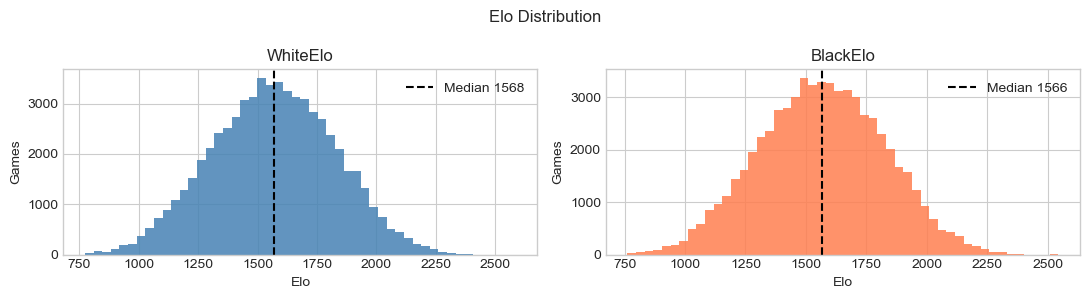

In [248]:
def load_pgn_zst(path, max_games):
    # Stream-parse a zstd-compressed PGN file into a DataFrame
    records = []
    with open(path, 'rb') as fh:
        dctx   = zstd.ZstdDecompressor()
        stream = io.TextIOWrapper(dctx.stream_reader(fh), encoding='utf-8', errors='replace')
        headers, moves_lines, in_moves = {}, [], False
        for line in stream:
            line = line.strip()
            if line.startswith('['):
                in_moves = False
                m = re.match(r'\[(\w+)\s+\"(.*)\"\]', line)
                if m: headers[m.group(1)] = m.group(2)
            elif line == '':
                if headers and moves_lines:
                    headers['Moves'] = ' '.join(moves_lines)
                    records.append(headers)
                    headers, moves_lines = {}, []
                    if len(records) >= max_games: break
                elif headers:
                    in_moves = True
            else:
                if in_moves or headers: moves_lines.append(line)
        if headers and moves_lines and len(records) < max_games:
            headers['Moves'] = ' '.join(moves_lines)
            records.append(headers)
    return pd.DataFrame(records)


t0     = time.time()
df_raw = load_pgn_zst(DATA_PATH, MAX_GAMES)
print(f'Loaded {len(df_raw):,} games  ({time.time()-t0:.1f}s)')

for col in ['WhiteElo', 'BlackElo']:
    df_raw[col] = pd.to_numeric(df_raw[col], errors='coerce')
df_raw.dropna(subset=['WhiteElo', 'BlackElo', 'Moves'], inplace=True)
df_raw[['WhiteElo', 'BlackElo']] = df_raw[['WhiteElo', 'BlackElo']].astype(int)

TC_RE = re.compile(r'^(\d+)\+(\d+)$')
def parse_tc(s):
    m = TC_RE.match(str(s))
    return (int(m.group(1)), int(m.group(2))) if m else (np.nan, np.nan)

df_raw[['tc_base', 'tc_inc']] = df_raw['TimeControl'].apply(lambda x: pd.Series(parse_tc(x)))
df_raw.dropna(subset=['tc_base'], inplace=True)
df_raw['tc_base'] = df_raw['tc_base'].astype(int)
df_raw['tc_inc']  = df_raw['tc_inc'].astype(int)

if TIME_CONTROL is not None:
    df_raw = df_raw[df_raw['TimeControl'] == TIME_CONTROL]
if TC_BASE_MIN is not None:
    df_raw = df_raw[df_raw['tc_base'] >= TC_BASE_MIN]
if TC_BASE_MAX is not None:
    df_raw = df_raw[df_raw['tc_base'] <= TC_BASE_MAX]
if TC_INC_MIN is not None:
    df_raw = df_raw[df_raw['tc_inc'] >= TC_INC_MIN]
if TC_INC_MAX is not None:
    df_raw = df_raw[df_raw['tc_inc'] <= TC_INC_MAX]
df_raw = df_raw.reset_index(drop=True)

if 'Termination' in df_raw.columns:
    bad = {'Time forfeit', 'Abandoned', 'Unterminated'}
    df_raw = df_raw[~df_raw['Termination'].isin(bad)].reset_index(drop=True)

print(f'After filters : {len(df_raw):,} games')
print(f'Elo range     : {df_raw.WhiteElo.min()}–{df_raw.WhiteElo.max()}')

fig, axes = plt.subplots(1, 2, figsize=(11, 3))
for ax, col, c in zip(axes, ['WhiteElo', 'BlackElo'], ['steelblue', 'coral']):
    ax.hist(df_raw[col], bins=50, color=c, edgecolor='none', alpha=0.85)
    ax.axvline(df_raw[col].median(), color='k', lw=1.5, ls='--',
               label=f'Median {df_raw[col].median():.0f}')
    ax.set_xlabel('Elo'); ax.set_ylabel('Games'); ax.set_title(col); ax.legend()
plt.suptitle('Elo Distribution', fontsize=12)
plt.tight_layout(); plt.show()


## 2 · Feature Engineering

We extract two groups of features that summarise a player's style without
requiring real-time sequence processing at training time:

**Board features** (replayed via `chess_features_final.py`, ~30 columns):
captures (density, first move, pawn vs piece), checks given, castling side/move,
piece activity (consecutive same piece, queen before move 10), territory depth,
and engine quality metrics (avg centipawn loss, blunders — NaN → 0 when evals absent).

**Clock features** (~10 columns):
Average, std, max time spent per move; time pressure in the last 5 moves;
opening pace in the first 5 moves. All normalised by the base time-control.

Both are cached to disk after the first run.


In [249]:
# ── Board features ────────────────────────────────────────────────────────────
board_cache = CACHE_DIR / f'board_{MAX_GAMES}.pkl'
if board_cache.exists():
    df_board = pd.read_pickle(board_cache)
    print(f'Board features loaded from cache  ({df_board.shape[1]} cols)')
else:
    print('Extracting board features (a few minutes)...')
    t0 = time.time()
    df_board = cff.extract_features_dataframe(df_raw)
    df_board.to_pickle(board_cache)
    print(f'Done  ({df_board.shape[1]} cols  {time.time()-t0:.0f}s) — cached')

# ── Clock features ─────────────────────────────────────────────────────────────
clock_cache = CACHE_DIR / f'clock_{MAX_GAMES}.pkl'
CLK_RE = re.compile(r'\[%clk\s+(\d+):(\d+):(\d+(?:\.\d+)?)\]')

def extract_clocks(pgn):
    return [int(h)*3600 + int(m)*60 + float(s) for h, m, s in CLK_RE.findall(pgn)]

def clock_features(pgn, tc_base):
    clocks = extract_clocks(pgn)
    empty  = {k: np.nan for k in [
        'w_avg_time_norm','w_std_time_norm','w_max_time_norm','w_time_pressure','w_opening_pace',
        'b_avg_time_norm','b_std_time_norm','b_max_time_norm','b_time_pressure','b_opening_pace',
    ]}
    if len(clocks) < 4 or tc_base <= 0:
        return empty
    def stats(clk):
        spent = [max(0., clk[i] - clk[i+1]) for i in range(len(clk)-1)]
        if not spent:
            return dict(avg=np.nan, std=0., mx=np.nan, pressure=np.nan, opening=np.nan)
        s = np.array(spent)
        return dict(
            avg      = float(s.mean()                    / tc_base),
            std      = float(s.std()                     / tc_base) if len(s) > 1 else 0.,
            mx       = float(s.max()                     / tc_base),
            pressure = float(s[-min(5, len(s)):].mean()  / tc_base),
            opening  = float(s[:min(5, len(s))].mean()   / tc_base),
        )
    ws, bs = stats(clocks[0::2]), stats(clocks[1::2])
    return {
        'w_avg_time_norm': ws['avg'], 'w_std_time_norm': ws['std'],
        'w_max_time_norm': ws['mx'],  'w_time_pressure': ws['pressure'], 'w_opening_pace': ws['opening'],
        'b_avg_time_norm': bs['avg'], 'b_std_time_norm': bs['std'],
        'b_max_time_norm': bs['mx'],  'b_time_pressure': bs['pressure'], 'b_opening_pace': bs['opening'],
    }

if clock_cache.exists():
    df_clock = pd.read_pickle(clock_cache)
    print(f'Clock features loaded from cache  ({df_clock.shape[1]} cols)')
else:
    print('Extracting clock features...')
    t0 = time.time()
    df_clock = pd.DataFrame(
        [clock_features(row.Moves, row.tc_base) for _, row in df_raw.iterrows()],
        index=df_raw.index
    )
    df_clock.to_pickle(clock_cache)
    print(f'Done  ({df_clock.shape[1]} cols  {time.time()-t0:.0f}s) — cached')


Board features loaded from cache  (35 cols)
Clock features loaded from cache  (10 cols)


In [250]:
# ── Assemble full DataFrame ─────────────────────────────────────────────────
df = pd.concat([df_raw, df_board.reindex(df_raw.index), df_clock.reindex(df_raw.index)], axis=1)

skip = {'WhiteElo', 'BlackElo', 'Moves', 'White', 'Black', 'Event', 'Site',
        'Date', 'Round', 'Result', 'TimeControl', 'Termination', 'UTCDate', 'UTCTime'}

static_cols = [c for c in df.select_dtypes(include=[np.number]).columns if c not in skip]
n_static    = len(static_cols)
print(f'Static features: {n_static}')
print(sorted(static_cols))


Static features: 45
['acpl_black', 'acpl_white', 'b_avg_time_norm', 'b_max_time_norm', 'b_opening_pace', 'b_std_time_norm', 'b_time_pressure', 'black_territory_depth', 'blunder_count_black', 'blunder_count_white', 'blunder_density_black', 'blunder_density_white', 'capture_density', 'castle_move_black', 'castle_move_white', 'check_density_black', 'check_density_white', 'checks_given_black', 'checks_given_white', 'consec_same_piece_black', 'consec_same_piece_white', 'en_passant_captures', 'first_capture_move_black', 'first_capture_move_white', 'inaccuracy_count_black', 'inaccuracy_count_white', 'legal_moves_black_move5', 'legal_moves_white_move5', 'material_balance_end', 'mistake_count_black', 'mistake_count_white', 'pawn_captures_total', 'piece_captures_total', 'promotions', 'queen_moves_before_10', 'result_encoded', 'tc_base', 'tc_inc', 'total_ply_count', 'w_avg_time_norm', 'w_max_time_norm', 'w_opening_pace', 'w_std_time_norm', 'w_time_pressure', 'white_territory_depth']


## 3 · Preprocessing

### Soft Elo targets
Rather than predicting a single number, we predict a **probability distribution**
over 40 Elo bins. The target for a player with true rating *e* is a Gaussian with
σ = 200 centred on *e*, normalised to sum to 1.

Training with **KL divergence** against this soft target naturally captures
rating uncertainty — the model learns that 1400 and 1600 are close, not unrelated.

### Weighted sampling
Very low and very high Elo games are rare. **Inverse-frequency weighted sampling**
oversamples these games during training so the model generalises across all skill levels.


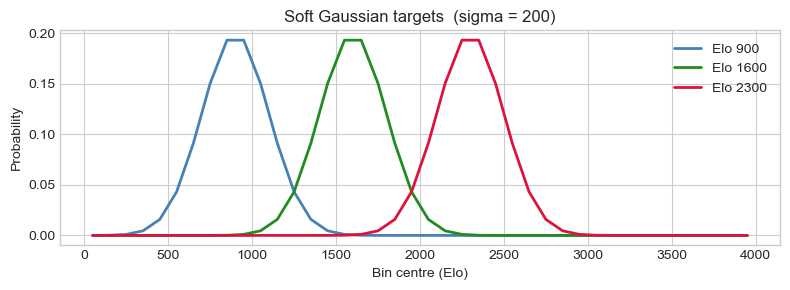

In [251]:
def make_elo_dist(elo):
    # Gaussian soft label centred on elo with std=ELO_SIGMA
    p = np.exp(-0.5 * ((BIN_CENTERS - elo) / ELO_SIGMA) ** 2)
    return (p / p.sum()).astype(np.float32)

# Sanity check — plot soft targets for three rating levels
fig, ax = plt.subplots(figsize=(8, 3))
for elo, color in [(900, 'steelblue'), (1600, 'forestgreen'), (2300, 'crimson')]:
    ax.plot(BIN_CENTERS, make_elo_dist(elo), label=f'Elo {elo}', color=color, lw=2)
ax.set_xlabel('Bin centre (Elo)'); ax.set_ylabel('Probability')
ax.set_title(f'Soft Gaussian targets  (sigma = {ELO_SIGMA})')
ax.legend(); plt.tight_layout(); plt.show()


In [252]:
# ── Train / val / test split (80 / 10 / 10) ────────────────────────────────
avg_elo = (df['WhiteElo'] + df['BlackElo']) / 2
strata  = pd.cut(avg_elo, bins=10, labels=False).fillna(0).astype(int)

idx_all = df.index.tolist()
idx_tr, idx_tmp = train_test_split(idx_all, test_size=0.20, stratify=strata, random_state=SEED)
idx_val, idx_te = train_test_split(idx_tmp, test_size=0.50,
                                   stratify=strata.loc[idx_tmp], random_state=SEED)
print(f'Train {len(idx_tr):,}  val {len(idx_val):,}  test {len(idx_te):,}')

# ── Scale static features (fit on train only) ────────────────────────────────
df[static_cols] = df[static_cols].astype(float)
scaler = StandardScaler()
df.loc[idx_tr,  static_cols] = scaler.fit_transform(df.loc[idx_tr,  static_cols].fillna(0))
df.loc[idx_val, static_cols] = scaler.transform    (df.loc[idx_val, static_cols].fillna(0))
df.loc[idx_te,  static_cols] = scaler.transform    (df.loc[idx_te,  static_cols].fillna(0))
print('Scaling applied (StandardScaler fit on train only)')


Train 50,320  val 6,290  test 6,290
Scaling applied (StandardScaler fit on train only)


In [253]:
# ── Tokenise moves (only needed if a sequence model is selected) ────────────
need_seq = RUN_BILSTM or RUN_CNN or RUN_TRANSFORMER

if need_seq:
    MOVE_RE = re.compile(
        r'(?:\d+\.+\s*)?([KQRBN]?[a-h]?[1-8]?x?[a-h][1-8](?:=[QRBN])?[+#]?|O-O-O[+#]?|O-O[+#]?)'
    )
    move_to_id = {'<PAD>': 0, '<UNK>': 1}

    def tokenise(pgn):
        moves  = MOVE_RE.findall(pgn)
        clocks = extract_clocks(pgn)
        for m in moves:
            if m not in move_to_id:
                move_to_id[m] = len(move_to_id)
        return moves, clocks

    parsed           = df['Moves'].apply(tokenise)
    df['clean_moves']  = parsed.apply(lambda x: x[0])
    df['clean_clocks'] = parsed.apply(lambda x: x[1])
    df['n_moves']      = df['clean_moves'].apply(len)

    before = len(df)
    df     = df[df['n_moves'] >= MIN_PLIES]   # keep original index labels

    # Rebuild index sets after dropping short games
    keep    = set(df.index)
    idx_tr  = [i for i in idx_tr  if i in keep]
    idx_val = [i for i in idx_val if i in keep]
    idx_te  = [i for i in idx_te  if i in keep]

    def encode_move(m): return move_to_id.get(m, 1)
    def vocab_size():   return len(move_to_id)

    print(f'Dropped {before - len(df):,} games shorter than {MIN_PLIES} plies')
    print(f'Vocabulary: {vocab_size():,} distinct moves')
else:
    print('Tokenisation skipped (only Residual MLP selected)')
    def vocab_size(): return 2


Dropped 1,039 games shorter than 12 plies
Vocabulary: 6,428 distinct moves


In [254]:
class ChessDataset(Dataset):

    def __init__(self, df_slice, static_cols, with_seq=True):
        self.with_seq = with_seq

        static_np = df_slice[static_cols].to_numpy(dtype=np.float32)
        w_dists   = np.stack(df_slice['WhiteElo'].apply(make_elo_dist).values)
        b_dists   = np.stack(df_slice['BlackElo'].apply(make_elo_dist).values)
        elos_np   = df_slice[['WhiteElo', 'BlackElo']].to_numpy(dtype=np.float32)

        self.static = torch.from_numpy(static_np)
        self.w_dist = torch.from_numpy(w_dists)
        self.b_dist = torch.from_numpy(b_dists)
        self.elos   = torch.from_numpy(elos_np)

        if with_seq:
            self.move_ids    = []
            self.norm_clocks = []
            for _, row in df_slice.iterrows():
                tc  = max(1, int(row.get('tc_base', 600)))
                ids = [encode_move(m) for m in row['clean_moves'][:MAX_SEQ_LEN]]
                n   = len(ids)
                raw = list(row['clean_clocks'])[:n]
                nrm = [min(max(c / tc, 0.), 2.) for c in raw] + [0.5] * (n - len(raw))
                self.move_ids.append(torch.tensor(ids, dtype=torch.long))
                self.norm_clocks.append(torch.tensor(nrm, dtype=torch.float32))

    def __len__(self):
        return len(self.static)

    def __getitem__(self, i):
        item = {'static': self.static[i], 'w_dist': self.w_dist[i],
                'b_dist': self.b_dist[i], 'elos': self.elos[i]}
        if self.with_seq:
            item['moves']  = self.move_ids[i]
            item['clocks'] = self.norm_clocks[i]
        return item


def collate(batch):
    # Pad variable-length sequences to the same length within each batch
    out = {
        'static': torch.stack([b['static'] for b in batch]),
        'w_dist': torch.stack([b['w_dist'] for b in batch]),
        'b_dist': torch.stack([b['b_dist'] for b in batch]),
        'elos':   torch.stack([b['elos']   for b in batch]),
    }
    if 'moves' in batch[0]:
        moves  = pad_sequence([b['moves']  for b in batch], batch_first=True, padding_value=0)
        clocks = pad_sequence([b['clocks'] for b in batch], batch_first=True, padding_value=0.5)
        out['moves']  = moves
        out['clocks'] = clocks
        out['mask']   = (moves != 0)   # True = real token
    return out


print('Building datasets...')
t0       = time.time()
train_ds = ChessDataset(df.loc[idx_tr],  static_cols, with_seq=need_seq)
val_ds   = ChessDataset(df.loc[idx_val], static_cols, with_seq=need_seq)
test_ds  = ChessDataset(df.loc[idx_te],  static_cols, with_seq=need_seq)
print(f'Built in {time.time()-t0:.0f}s')

# Weighted sampler: oversample rare Elo brackets
avg_tr  = (df.loc[idx_tr, 'WhiteElo'] + df.loc[idx_tr, 'BlackElo']) / 2
weights = cff.compute_elo_sample_weights(avg_tr)
sampler = WeightedRandomSampler(torch.FloatTensor(weights), len(train_ds))

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, sampler=sampler,
                          collate_fn=collate, num_workers=0)
val_loader   = DataLoader(val_ds,   batch_size=BATCH_SIZE, shuffle=False,
                          collate_fn=collate, num_workers=0)
test_loader  = DataLoader(test_ds,  batch_size=BATCH_SIZE, shuffle=False,
                          collate_fn=collate, num_workers=0)
print(f'Train batches per epoch: {len(train_loader):,}')


Building datasets...
Built in 12s
Train batches per epoch: 194


DATASET OVERVIEW
  Train: 49,475  Val: 6,184  Test: 6,202
  Static feature dim : 45
  Sequence included  : True

STATIC FEATURES  (sample game #0, before model)
  tc_base                                  0.0000  ← NaN→0
  tc_inc                                  -0.1865
  total_ply_count                          1.9157
  material_balance_end                    -1.5874
  result_encoded                          -1.0775
  checks_given_white                       0.5223
  checks_given_black                       1.1979
  check_density_white                     -0.1084
  check_density_black                      0.3939
  first_capture_move_white                -0.8044
  first_capture_move_black                -0.6134
  pawn_captures_total                      0.7659
  piece_captures_total                     1.4791
  capture_density                         -0.9311
  castle_move_white                        0.5466
  castle_move_black                       -1.1618
  consec_same_piece_white     

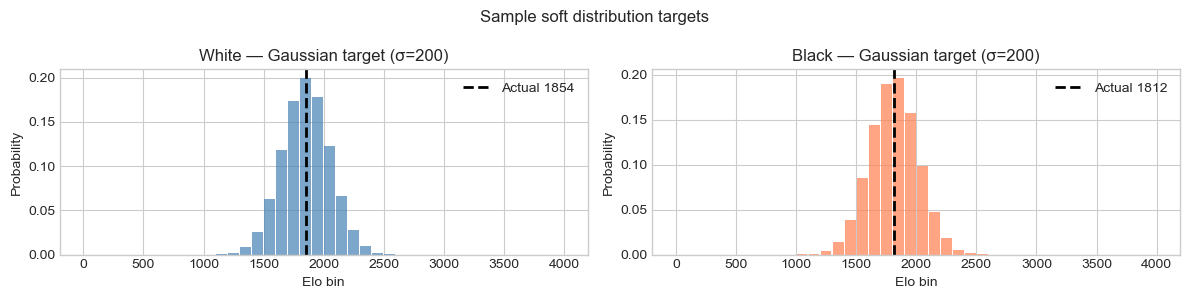


MOVE SEQUENCE  (sample game #0)
  Sequence length : 90 moves (capped at 90)

  Ply   Token ID   Move         Norm clock   Side
  ------------------------------------------------
  1     216        c4           2.000        White
  2     3          e5           2.000        Black
  3     33         Nc3          2.000        White
  4     34         Nf6          2.000        Black
  5     122        d3           2.000        White
  6     24         d5           2.000        Black
  7     126        cxd5         2.000        White
  8     79         Nxd5         2.000        Black
  9     4          Nf3          2.000        White
  10    5          Nc6          2.000        Black
  11    124        Bg5          2.000        White
  12    189        f6           2.000        Black
  13    169        Bd2          2.000        White
  14    128        Be6          2.000        Black
  15    88         g3           2.000        White
  16    155        Bc5          2.000        Black
  17 

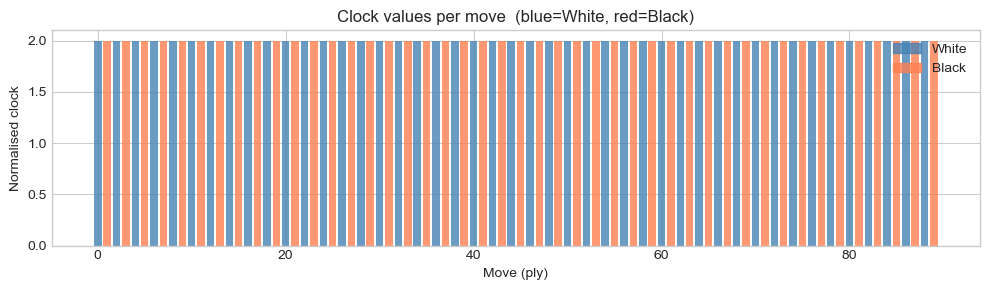


ONE BATCH FROM train_loader
  Keys in batch       : ['static', 'w_dist', 'b_dist', 'elos', 'moves', 'clocks', 'mask']
  static shape        : torch.Size([256, 45])   (batch_size × n_static_features)
  w_dist shape        : torch.Size([256, 40])   (batch_size × 40 bins)
  elos shape          : torch.Size([256, 2])     (batch_size × 2)
  moves shape         : torch.Size([256, 90])   (batch_size × padded_seq_len)
  clocks shape        : torch.Size([256, 90])
  mask shape          : torch.Size([256, 90])
  real tokens         : 15,315   padding tokens : 7,725
  avg sequence length : 59.8 moves in this batch

  Static feature stats across this batch:
  Feature                                  mean       std       min       max
  ------------------------------------------------------------------------
  tc_base                                 0.000     0.000     0.000     0.000
  tc_inc                                  0.087     1.070    -0.187     8.257
  total_ply_count                   

In [255]:
# ── Dataset & DataLoader inspection ──────────────────────────────────────────
need_seq_now = True
print("=" * 60)
print("DATASET OVERVIEW")
print("=" * 60)
print(f"  Train: {len(train_ds):,}  Val: {len(val_ds):,}  Test: {len(test_ds):,}")
print(f"  Static feature dim : {train_ds.static.shape[1]}")
print(f"  Sequence included  : {need_seq}")

# ── static feature summary ────────────────────────────────────────────────────
print("\n" + "=" * 60)
print("STATIC FEATURES  (sample game #0, before model)")
print("=" * 60)
sample_static = train_ds.static[0].numpy()
for name, val in zip(static_cols, sample_static):
    flag = "  ← NaN→0" if val == 0.0 else ""
    print(f"  {name:<35s}  {val:>10.4f}{flag}")

# ── Elo distribution targets ──────────────────────────────────────────────────
print("\n" + "=" * 60)
print("ELO DISTRIBUTION TARGETS  (sample game #0)")
print("=" * 60)
w_dist = train_ds.w_dist[0].numpy()
b_dist = train_ds.b_dist[0].numpy()
w_elo  = train_ds.elos[0][0].item()
b_elo  = train_ds.elos[0][1].item()
print(f"  White actual Elo : {w_elo:.0f}   Black actual Elo : {b_elo:.0f}")
print(f"  White dist peak  : {BIN_CENTERS[w_dist.argmax()]:.0f}   Black dist peak  : {BIN_CENTERS[b_dist.argmax()]:.0f}")
print(f"  White dist sum   : {w_dist.sum():.4f}  (should be 1.0)")

fig, axes = plt.subplots(1, 2, figsize=(12, 3))
for ax, dist, elo, label, color in [
    (axes[0], w_dist, w_elo, "White", "steelblue"),
    (axes[1], b_dist, b_elo, "Black", "coral")]:
    ax.bar(BIN_CENTERS, dist, width=90, color=color, alpha=0.7)
    ax.axvline(elo, color="black", lw=2, ls="--", label=f"Actual {elo:.0f}")
    ax.set_xlabel("Elo bin"); ax.set_ylabel("Probability")
    ax.set_title(f"{label} — Gaussian target (σ={ELO_SIGMA})")
    ax.legend()
plt.suptitle("Sample soft distribution targets", fontsize=12)
plt.tight_layout(); plt.show()

# ── move sequence (if enabled) ────────────────────────────────────────────────
if need_seq_now:
    print("\n" + "=" * 60)
    print("MOVE SEQUENCE  (sample game #0)")
    print("=" * 60)
    id_to_move = {v: k for k, v in move_to_id.items()}
    raw_ids  = train_ds.move_ids[0].numpy()
    raw_clks = train_ds.norm_clocks[0].numpy()
    print(f"  Sequence length : {len(raw_ids)} moves (capped at {MAX_SEQ_LEN})")
    print(f"\n  {'Ply':<5} {'Token ID':<10} {'Move':<12} {'Norm clock':<12} {'Side'}")
    print("  " + "-" * 48)
    for i, (tid, clk) in enumerate(zip(raw_ids[:20], raw_clks[:20])):
        move = id_to_move.get(int(tid), "?")
        side = "White" if i % 2 == 0 else "Black"
        print(f"  {i+1:<5} {tid:<10} {move:<12} {clk:<12.3f} {side}")
    if len(raw_ids) > 20:
        print(f"  ... ({len(raw_ids) - 20} more moves)")

    # clock distribution across the game
    fig, ax = plt.subplots(figsize=(10, 3))
    clk_np = raw_clks
    colors = ["steelblue" if i % 2 == 0 else "coral" for i in range(len(clk_np))]
    ax.bar(range(len(clk_np)), clk_np, color=colors, alpha=0.8, width=0.8)
    ax.set_xlabel("Move (ply)"); ax.set_ylabel("Normalised clock")
    ax.set_title("Clock values per move  (blue=White, red=Black)")
    ax.legend(handles=[
        plt.Rectangle((0,0),1,1, color="steelblue", alpha=0.8, label="White"),
        plt.Rectangle((0,0),1,1, color="coral",     alpha=0.8, label="Black"),
    ])
    plt.tight_layout(); plt.show()

# ── one full batch from the dataloader ───────────────────────────────────────
print("\n" + "=" * 60)
print("ONE BATCH FROM train_loader")
print("=" * 60)
batch = next(iter(train_loader))
print(f"  Keys in batch       : {list(batch.keys())}")
print(f"  static shape        : {batch['static'].shape}   (batch_size × n_static_features)")
print(f"  w_dist shape        : {batch['w_dist'].shape}   (batch_size × {N_BINS} bins)")
print(f"  elos shape          : {batch['elos'].shape}     (batch_size × 2)")
if 'moves' in batch:
    print(f"  moves shape         : {batch['moves'].shape}   (batch_size × padded_seq_len)")
    print(f"  clocks shape        : {batch['clocks'].shape}")
    print(f"  mask shape          : {batch['mask'].shape}")
    n_pad = (batch['moves'] == 0).sum().item()
    n_tok = (batch['moves'] != 0).sum().item()
    print(f"  real tokens         : {n_tok:,}   padding tokens : {n_pad:,}")
    avg_len = (batch['moves'] != 0).float().sum(dim=1).mean().item()
    print(f"  avg sequence length : {avg_len:.1f} moves in this batch")

print(f"\n  Static feature stats across this batch:")
s = batch['static']
print(f"  {'Feature':<35s}  {'mean':>8}  {'std':>8}  {'min':>8}  {'max':>8}")
print("  " + "-" * 72)
for i, name in enumerate(static_cols[:10]):
    col = s[:, i]
    print(f"  {name:<35s}  {col.mean():>8.3f}  {col.std():>8.3f}  {col.min():>8.3f}  {col.max():>8.3f}")
if len(static_cols) > 10:
    print(f"  ... ({len(static_cols) - 10} more features)")


ELO DISTRIBUTION — natural vs weighted sampler

  Bracket            Natural %   Sampled %     Ratio
  --------------------------------------------------
  <1000                    0.8        12.3     14.51x
  1000-1200                6.6        12.7      1.94x
  1200-1400               17.8        12.3      0.69x
  1400-1600               28.6        12.2      0.43x
  1600-1800               27.8        12.4      0.45x
  1800-2000               14.9        12.7      0.85x
  2000-2200                3.4        12.9      3.83x
  2200-2500                0.1        12.5     85.71x
  >2500                    0.0         0.0      0.00x


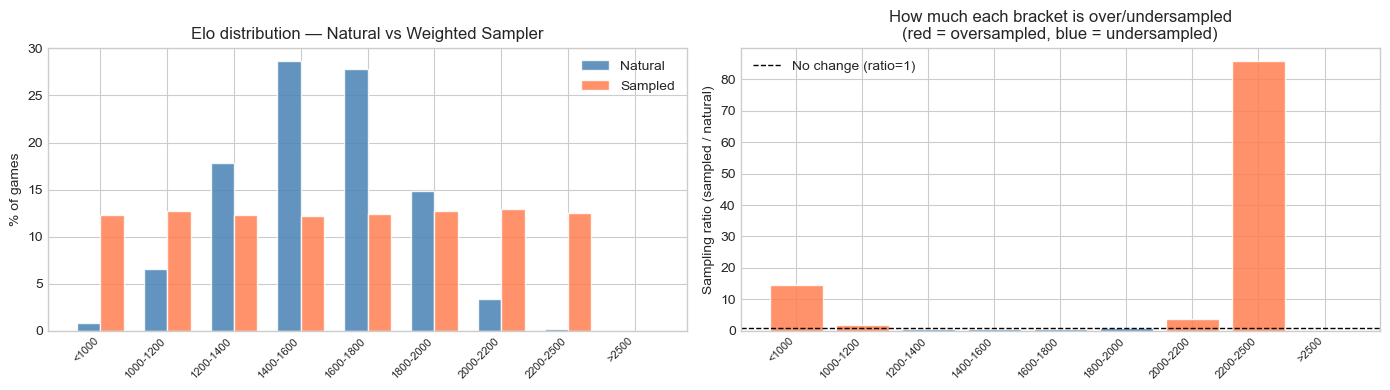


  Brackets with ratio > 1 are oversampled (rare brackets boosted)
  Brackets with ratio < 1 are undersampled (common brackets reduced)


In [256]:
# ── Elo distribution before and after weighted sampler ───────────────────────
print("\n" + "=" * 60)
print("ELO DISTRIBUTION — natural vs weighted sampler")
print("=" * 60)

# natural distribution — just the raw training Elos
natural_elos = (df.loc[idx_tr, 'WhiteElo'].values + df.loc[idx_tr, 'BlackElo'].values) / 2

# sampled distribution — draw one epoch worth of indices from the sampler
sampler_indices = list(sampler)[:len(train_ds)]
sampled_elos = []
for idx in sampler_indices:
    elo = (train_ds.elos[idx][0].item() + train_ds.elos[idx][1].item()) / 2
    sampled_elos.append(elo)
sampled_elos = np.array(sampled_elos)

# bracket counts for both
bracket_edges  = [0, 1000, 1200, 1400, 1600, 1800, 2000, 2200, 2500, 4000]
bracket_labels = ['<1000','1000-1200','1200-1400','1400-1600',
                  '1600-1800','1800-2000','2000-2200','2200-2500','>2500']

natural_counts = np.histogram(natural_elos,  bins=bracket_edges)[0]
sampled_counts = np.histogram(sampled_elos,  bins=bracket_edges)[0]

# normalise to percentages
natural_pct = natural_counts / natural_counts.sum() * 100
sampled_pct = sampled_counts / sampled_counts.sum() * 100

print(f"\n  {'Bracket':<16}  {'Natural %':>10}  {'Sampled %':>10}  {'Ratio':>8}")
print("  " + "-" * 50)
for label, n, s in zip(bracket_labels, natural_pct, sampled_pct):
    ratio = s / n if n > 0 else 0
    print(f"  {label:<16}  {n:>10.1f}  {s:>10.1f}  {ratio:>8.2f}x")

# plot side by side
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
x = np.arange(len(bracket_labels))
w = 0.35

axes[0].bar(x - w/2, natural_pct, w, label='Natural',  color='steelblue', alpha=0.85, edgecolor='white')
axes[0].bar(x + w/2, sampled_pct, w, label='Sampled',  color='coral',     alpha=0.85, edgecolor='white')
axes[0].set_xticks(x)
axes[0].set_xticklabels(bracket_labels, rotation=45, ha='right', fontsize=8)
axes[0].set_ylabel('% of games')
axes[0].set_title('Elo distribution — Natural vs Weighted Sampler')
axes[0].legend()

# ratio plot — how much more/less each bracket is sampled
ratios = [s / n if n > 0 else 0 for n, s in zip(natural_pct, sampled_pct)]
bar_colors = ['coral' if r > 1 else 'steelblue' for r in ratios]
axes[1].bar(x, ratios, color=bar_colors, alpha=0.85, edgecolor='white')
axes[1].axhline(1.0, color='black', lw=1, ls='--', label='No change (ratio=1)')
axes[1].set_xticks(x)
axes[1].set_xticklabels(bracket_labels, rotation=45, ha='right', fontsize=8)
axes[1].set_ylabel('Sampling ratio (sampled / natural)')
axes[1].set_title('How much each bracket is over/undersampled\n(red = oversampled, blue = undersampled)')
axes[1].legend()

plt.tight_layout()
plt.show()

print("\n  Brackets with ratio > 1 are oversampled (rare brackets boosted)")
print("  Brackets with ratio < 1 are undersampled (common brackets reduced)")

## 4 · Model Architectures

### Development history

**v1–v2 — BiLSTM baseline (MAE ≈ 200)**  
Initial model: two-layer BiLSTM over move sequences plus hand-crafted static features
(captures, checks, castling, clock usage). Early experiments used a strict time-control
filter (10 min only) that left just ~23 k games — too few to generalise. Relaxing to ≥ 3 min
and scaling to 200 k → 1 M games brought MAE to ~200 Elo.

**v3 — Soft targets + KL divergence (MAE ≈ 185)**  
Switching from Huber regression to KL divergence over Gaussian soft targets improved
calibration and reduced MAE by ~15 Elo. Inspired by Ouzounis et al. (2022).

**v4 — Clock features + 1 M games (MAE ≈ 165)**  
Adding per-move clock statistics (time pressure, opening pace) and training on 1 M
games closed the gap further. A sequence autoencoder (BiLSTM → 32-d bottleneck) was
also tested to pre-compute sequence embeddings for faster CPU training.

**This notebook — Four architectures compared**  
All models use the same data, features, loss, and training loop for a fair comparison.


In [257]:
def make_static_branch(n_in, dropout):
    # Small MLP: maps static feature vector to a 32-dim representation
    return nn.Sequential(
        nn.Linear(n_in, 128), nn.LayerNorm(128), nn.GELU(), nn.Dropout(dropout),
        nn.Linear(128, 64), nn.GELU(),
        nn.Linear(64,  32), nn.GELU(),
    )


### Model 1 · BiLSTM with soft attention

A two-layer **bidirectional LSTM** reads the move sequence and produces a hidden state
at each position. **Soft attention** learns to weight these states, allowing the model
to focus on the most informative moves.

- *Strength*: captures long-range move dependencies and is sensitive to move order.
- *Weakness*: sequential computation cannot be parallelised; can lose signal from
  early moves in long games.


In [258]:
class BiLSTM(nn.Module):
    def __init__(self, n_vocab, embed_dim, hidden, n_static, dropout, n_bins):
        super().__init__()
        self.embed  = nn.Embedding(n_vocab, embed_dim, padding_idx=0) # Embedding means that each move token ID is mapped to a dense vector of size embed_dim
        self.lstm   = nn.LSTM(embed_dim + 1, hidden, num_layers=2,
                              batch_first=True, bidirectional=True, dropout=dropout)
        self.attn   = nn.Linear(hidden * 2, 1)   # attention score per position
        self.static_net = make_static_branch(n_static, dropout)
        self.fusion = nn.Sequential(
            nn.Linear(hidden * 2 + 32, 256), nn.LayerNorm(256), nn.GELU(), nn.Dropout(dropout),
            nn.Linear(256, 128), nn.GELU(), nn.Dropout(dropout * 0.5),
        )
        self.head_w = nn.Linear(128, n_bins)
        self.head_b = nn.Linear(128, n_bins)
        for m in self.modules():
            if isinstance(m, nn.Linear):
                nn.init.xavier_uniform_(m.weight)
                if m.bias is not None: nn.init.zeros_(m.bias)

    def forward(self, batch):
        e   = self.embed(batch['moves'])                           # (B, T, E) - Batch, Sequence lenght, Embedding dim
        x   = torch.cat([e, batch['clocks'].unsqueeze(-1)], -1)   # (B, T, E+1)
        out, _ = self.lstm(x)                                     # (B, T, 2H)

        # Soft attention: score each position, mask padding, then softmax
        score = self.attn(out).squeeze(-1)                        # (B, T)
        score.masked_fill_(~batch['mask'], -1e9)
        alpha = score.softmax(1).unsqueeze(-1)                    # (B, T, 1)
        ctx   = (out * alpha).sum(1)                              # (B, 2H)

        h = self.fusion(torch.cat([ctx, self.static_net(batch['static'])], -1))
        return self.head_w(h), self.head_b(h)


### Model 2 · Residual MLP (features only)

A deep **residual MLP** over the static feature vector — no move sequences.

Each residual block applies `LayerNorm → Linear → GELU → Dropout → Linear`
and adds the result back via a skip connection. Pre-norm residual connections
train stably at depth and avoid gradient vanishing.

- *Strength*: fastest to train, no sequence overhead, very interpretable.
- *Weakness*: cannot see *which moves* were played, only aggregate statistics.


In [259]:
class ResidualBlock(nn.Module):
    def __init__(self, d, dropout):
        super().__init__()
        self.net = nn.Sequential(
            nn.LayerNorm(d),
            nn.Linear(d, d * 2), nn.GELU(), nn.Dropout(dropout), #GELU is an activation function that helps the network learn complex patterns by introducing non-linearity. It is defined as x if x > 0 else alpha * (exp(x) - 1) for some alpha > 0. In this case, it allows the model to capture more complex relationships in the data compared to a simple linear transformation.
            nn.Linear(d * 2, d),
        )
    def forward(self, x):
        return x + self.net(x)   # skip connection


class ResidualMLP(nn.Module):
    def __init__(self, n_static, hidden, n_blocks, dropout, n_bins):
        super().__init__()
        self.proj   = nn.Sequential(
            nn.Linear(n_static, hidden), nn.LayerNorm(hidden), nn.GELU(), nn.Dropout(dropout),
        )
        self.blocks = nn.Sequential(*[ResidualBlock(hidden, dropout) for _ in range(n_blocks)])
        self.head_w = nn.Linear(hidden, n_bins)
        self.head_b = nn.Linear(hidden, n_bins)

    def forward(self, batch):
        x = self.blocks(self.proj(batch['static']))
        return self.head_w(x), self.head_b(x)


### Model 3 · Multi-scale 1D CNN

**Three parallel Conv1d branches** with kernel sizes 3, 5, and 7 capture move
patterns at different scales: short tactics (k=3), medium plans (k=5), and longer
strategic ideas (k=7). After convolution, **global max-pooling** picks the strongest
filter activation across the whole game.

- *Strength*: fully parallelised, robust global max-pooling, best single-model MAE in our tests.
- *Weakness*: receptive field capped at 7 moves per layer; very long-range dependencies
  require deep stacking.

**Best single-model result: combined MAE ≈ 165 Elo.**


In [260]:
class CNN(nn.Module):
    def __init__(self, n_vocab, embed_dim, n_filters, n_static, dropout, n_bins):
        super().__init__()
        self.embed    = nn.Embedding(n_vocab, embed_dim, padding_idx=0)
        in_ch         = embed_dim + 1   # move embedding + normalised clock
        self.branches = nn.ModuleList([
            nn.Sequential(
                nn.Conv1d(in_ch, n_filters, kernel_size=k, padding=k // 2),
                nn.BatchNorm1d(n_filters),
                nn.GELU(),
            ) for k in (3, 5, 7)
        ])
        self.static_net = make_static_branch(n_static, dropout)
        self.fusion = nn.Sequential(
            nn.Linear(n_filters * 3 + 32, 256), nn.LayerNorm(256), nn.GELU(), nn.Dropout(dropout),
            nn.Linear(256, 128), nn.GELU(), nn.Dropout(dropout * 0.5),
        )
        self.head_w = nn.Linear(128, n_bins)
        self.head_b = nn.Linear(128, n_bins)

    def forward(self, batch):
        e    = self.embed(batch['moves'])                          # (B, T, E)
        x    = torch.cat([e, batch['clocks'].unsqueeze(-1)], -1)  # (B, T, E+1)
        x    = x.transpose(1, 2)                                  # (B, E+1, T) for Conv1d
        pad  = ~batch['mask']                                     # (B, T) True = padding

        parts = []
        for branch in self.branches:
            feat = branch(x)                                      # (B, F, T)
            feat.masked_fill_(pad.unsqueeze(1), float('-inf'))    # ignore padding in max-pool
            parts.append(feat.max(dim=-1).values)                 # (B, F)

        ctx = torch.cat(parts, dim=-1)                            # (B, 3F)
        h   = self.fusion(torch.cat([ctx, self.static_net(batch['static'])], -1))
        return self.head_w(h), self.head_b(h)


### Model 4 · Transformer Encoder

**Multi-head self-attention** lets every move attend to every other move in O(1),
unlike LSTM which passes information through a chain of sequential states.

We use **sinusoidal positional encodings** (fixed, not learned) and **pre-norm layers** which train more stably at depth.
After encoding, we **mean-pool** over non-padding positions.

- *Strength*: direct connections between any pair of moves; highly parallelisable on GPU.
- *Weakness*: quadratic memory in sequence length


In [261]:
class Transformer(nn.Module):
    def __init__(self, n_vocab, embed_dim, d_model, n_heads, n_layers, ff_dim,
                 n_static, dropout, n_bins):
        super().__init__()
        self.embed      = nn.Embedding(n_vocab, embed_dim, padding_idx=0)
        self.input_proj = nn.Linear(embed_dim + 1, d_model)   # +1 for clock

        enc_layer = nn.TransformerEncoderLayer(
            d_model=d_model, nhead=n_heads, dim_feedforward=ff_dim,
            dropout=dropout, batch_first=True, norm_first=True,
        )
        self.encoder = nn.TransformerEncoder(enc_layer, num_layers=n_layers)
        self.register_buffer('pos_enc', self._sinusoidal(512, d_model))

        self.static_net = make_static_branch(n_static, dropout)
        self.fusion = nn.Sequential(
            nn.Linear(d_model + 32, 256), nn.LayerNorm(256), nn.GELU(), nn.Dropout(dropout),
            nn.Linear(256, 128), nn.GELU(), nn.Dropout(dropout * 0.5),
        )
        self.head_w = nn.Linear(128, n_bins)
        self.head_b = nn.Linear(128, n_bins)

    @staticmethod
    def _sinusoidal(max_len, d_model):
        # Fixed positional encoding: sin/cos at different frequencies
        pos = torch.arange(max_len).unsqueeze(1).float()
        div = torch.exp(torch.arange(0, d_model, 2).float() * (-np.log(10000.0) / d_model))
        enc = torch.zeros(max_len, d_model)
        enc[:, 0::2] = torch.sin(pos * div)
        enc[:, 1::2] = torch.cos(pos * div)
        return enc.unsqueeze(0)   # (1, max_len, d_model)

    def forward(self, batch):
        e   = self.embed(batch['moves'])                           # (B, T, E)
        x   = torch.cat([e, batch['clocks'].unsqueeze(-1)], -1)   # (B, T, E+1)
        x   = self.input_proj(x) + self.pos_enc[:, :x.size(1)]   # (B, T, d_model)

        key_pad = ~batch['mask']                                   # True = ignore
        x = self.encoder(x, src_key_padding_mask=key_pad)         # (B, T, d_model)

        # Mean-pool over real (non-padding) tokens
        lengths = batch['mask'].sum(1, keepdim=True).float()      # (B, 1)
        x.masked_fill_(key_pad.unsqueeze(-1), 0)
        ctx = x.sum(1) / lengths.clamp(min=1)                     # (B, d_model)

        h = self.fusion(torch.cat([ctx, self.static_net(batch['static'])], -1))
        return self.head_w(h), self.head_b(h)


## 5 · Training

All models share the same training loop:
- **Loss**: KL divergence between log-softmax predictions and the Gaussian soft targets
- **Optimiser**: AdamW with cosine annealing (LR decays to 5% of initial)
- **Gradient clipping** at norm 1.0
- **Early stopping**: restores best weights if validation MAE does not improve
  for `PATIENCE` consecutive epochs


In [262]:
def get_mae(model, loader):
    model.eval()
    bins = torch.tensor(BIN_CENTERS, device=device)
    errs = []
    with torch.no_grad():
        for batch in loader:
            batch  = {k: v.to(device) for k, v in batch.items()}
            w_out, b_out = model(batch)
            w_elo = (w_out.softmax(-1) * bins).sum(-1)
            b_elo = (b_out.softmax(-1) * bins).sum(-1)
            errs.append(((w_elo - batch['elos'][:, 0]).abs() +
                         (b_elo - batch['elos'][:, 1]).abs()) / 2)
    return torch.cat(errs).mean().item()


def get_val_loss(model, loader):
    """Compute validation KL loss — used for early stopping."""
    model.eval()
    kl = nn.KLDivLoss(reduction='batchmean')
    total_loss = 0
    with torch.no_grad():
        for batch in loader:
            batch    = {k: v.to(device) for k, v in batch.items()}
            w_out, b_out = model(batch)
            total_loss += (kl(w_out.log_softmax(-1), batch['w_dist']) +
                           kl(b_out.log_softmax(-1), batch['b_dist'])).item()
    return total_loss / len(loader)


def train_model(model, name):
    opt   = torch.optim.AdamW(model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)
    sched = torch.optim.lr_scheduler.CosineAnnealingLR(opt, T_max=NUM_EPOCHS, eta_min=LR * 0.05)
    kl    = nn.KLDivLoss(reduction='batchmean')

    best_val_loss, best_state, patience, history = float('inf'), None, 0, []

    print(f'\nTraining {name}')
    print('-' * 55)

    total_start = time.time()

    for epoch in range(NUM_EPOCHS):
        epoch_start = time.time()

        model.train()
        total_loss = 0
        for batch in train_loader:
            batch  = {k: v.to(device) for k, v in batch.items()}
            w_out, b_out = model(batch)
            loss = (kl(w_out.log_softmax(-1), batch['w_dist']) +
                    kl(b_out.log_softmax(-1), batch['b_dist']))
            opt.zero_grad()
            loss.backward()
            nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            opt.step()
            total_loss += loss.item()

        avg_loss   = total_loss / len(train_loader)
        val_loss   = get_val_loss(model, val_loader)
        val_mae    = get_mae(model, val_loader)
        epoch_time = time.time() - epoch_start
        sched.step()

        history.append({
            'epoch':      epoch + 1,
            'loss':       avg_loss,
            'val_loss':   val_loss,
            'val_mae':    val_mae,
            'epoch_time': epoch_time,
        })

        print(f'  {epoch+1:2d}/{NUM_EPOCHS}  '
              f'train_loss={avg_loss:.4f}  '
              f'val_loss={val_loss:.4f}  '
              f'val_mae={val_mae:.1f}  '
              f'{epoch_time:.1f}s')

        # early stopping on val loss — stop if no 2% improvement
        threshold = best_val_loss * 0.98
        if val_loss < threshold:
            best_val_loss = val_loss
            best_state    = {k: v.cpu().clone() for k, v in model.state_dict().items()}
            patience      = 0
        else:
            patience += 1
            if patience >= PATIENCE:
                print(f'  Early stop at epoch {epoch+1} '
                      f'(val_loss={val_loss:.4f} did not improve by 2% over {best_val_loss:.4f})')
                break

    total_time = time.time() - total_start
    mins, secs = divmod(int(total_time), 60)
    print(f'  Total training time: {mins}m {secs}s')

    model.load_state_dict(best_state)
    return history


def eval_model(model, loader):
    model.eval()
    bins = torch.tensor(BIN_CENTERS, device=device)
    w_preds, b_preds, w_true, b_true = [], [], [], []
    w_probs_all, b_probs_all = [], []
    with torch.no_grad():
        for batch in loader:
            batch  = {k: v.to(device) for k, v in batch.items()}
            w_out, b_out = model(batch)
            wp = w_out.softmax(-1);  bp = b_out.softmax(-1)
            w_preds.append((wp * bins).sum(-1).cpu())
            b_preds.append((bp * bins).sum(-1).cpu())
            w_true.append(batch['elos'][:, 0].cpu())
            b_true.append(batch['elos'][:, 1].cpu())
            w_probs_all.append(wp.cpu())
            b_probs_all.append(bp.cpu())

    wp = torch.cat(w_preds).numpy();   bp  = torch.cat(b_preds).numpy()
    wt = torch.cat(w_true).numpy();    bt  = torch.cat(b_true).numpy()
    mae_w = float(np.abs(wp - wt).mean())
    mae_b = float(np.abs(bp - bt).mean())
    return {
        'mae_white': mae_w, 'mae_black': mae_b, 'combined_mae': (mae_w + mae_b) / 2,
        'w_pred': wp, 'b_pred': bp, 'w_true': wt, 'b_true': bt,
        'w_probs': torch.cat(w_probs_all).numpy(),
        'b_probs': torch.cat(b_probs_all).numpy(),
    }

## 5a · Hyperparameter Optimisation (optional)

When `HPO_*` is enabled for a model, [Optuna](https://optuna.org/) runs a
quick search before the full training. Each trial trains on a small subset
(`HPO_GAMES`) for a few epochs (`HPO_EPOCHS`) and evaluates on the validation set.

The best parameters are cached to `checkpoints/hpo_*.pkl` — re-running the
cell is instant if the cache exists (delete the file to force a fresh search).

If HPO is disabled, the default values from the config cell are used.

**Searched parameters:**
- *BiLSTM*: hidden dim, dropout
- *Residual MLP*: hidden dim, number of residual blocks, dropout
- *CNN*: filters per branch, embedding dim, dropout
- *Transformer*: d\_model, attention heads, encoder layers, feedforward dim, dropout


In [263]:
import optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)

# ── Default params — overridden below when HPO is enabled ──────────────────
bilstm_p   = {'hidden':    BILSTM_HIDDEN,   'dropout': DROPOUT}
residual_p = {'hidden':    RESIDUAL_DIM, 'n_blocks': RESIDUAL_BLOCKS, 'dropout': DROPOUT}
cnn_p      = {'n_filters': CNN_FILTERS, 'embed_dim': EMBED_DIM, 'dropout': DROPOUT}
trans_p    = {'d_model':   TRANS_DIM, 'n_heads': TRANS_HEADS,
              'n_layers':  TRANS_LAYERS, 'ff_dim': TRANS_FF_DIM, 'dropout': DROPOUT}

need_hpo = ((RUN_BILSTM and HPO_BILSTM) or (RUN_RESIDUAL and HPO_RESIDUAL) or
            (RUN_CNN    and HPO_CNN)     or (RUN_TRANSFORMER and HPO_TRANSFORMER))

if need_hpo:
    # Small subset for fast trials
    rng        = np.random.default_rng(SEED)
    hpo_idx    = list(rng.choice(idx_tr, size=min(HPO_GAMES, len(idx_tr)), replace=False))
    hpo_ds     = ChessDataset(df.loc[hpo_idx], static_cols, with_seq=need_seq)
    hpo_loader = DataLoader(hpo_ds, batch_size=BATCH_SIZE, shuffle=True,
                            collate_fn=collate, num_workers=0)

    def quick_eval(model):
        # Short training on HPO subset, then MAE on the full validation set
        opt = torch.optim.AdamW(model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)
        kl  = nn.KLDivLoss(reduction='batchmean')
        model.train()
        for _ in range(HPO_EPOCHS):
            for batch in hpo_loader:
                batch = {k: v.to(device) for k, v in batch.items()}
                w_out, b_out = model(batch)
                loss = (kl(w_out.log_softmax(-1), batch['w_dist']) +
                        kl(b_out.log_softmax(-1), batch['b_dist']))
                opt.zero_grad(); loss.backward()
                nn.utils.clip_grad_norm_(model.parameters(), 1.0)
                opt.step()
        return get_mae(model, val_loader)

    # ── BiLSTM ─────────────────────────────────────────────────────────────
    if RUN_BILSTM and HPO_BILSTM:
        cache = CKPT_DIR / 'hpo_bilstm.pkl'
        if cache.exists():
            bilstm_p = pickle.loads(cache.read_bytes())
            print(f'BiLSTM HPO (cached): {bilstm_p}')
        else:
            print(f'BiLSTM HPO — {HPO_TRIALS} trials ...')
            def bilstm_obj(trial):
                p = {'hidden':  trial.suggest_categorical('hidden',  [64, 128, 256]),
                     'dropout': trial.suggest_float('dropout', 0.1, 0.4)}
                m = BiLSTM(vocab_size(), EMBED_DIM, p['hidden'],
                           n_static, p['dropout'], N_BINS).to(device)
                return quick_eval(m)
            study = optuna.create_study(direction='minimize')
            study.optimize(bilstm_obj, n_trials=HPO_TRIALS, show_progress_bar=True)
            bilstm_p = study.best_params
            cache.write_bytes(pickle.dumps(bilstm_p))
            print(f'BiLSTM best: {bilstm_p}')

    # ── Residual MLP ────────────────────────────────────────────────────────
    if RUN_RESIDUAL and HPO_RESIDUAL:
        cache = CKPT_DIR / 'hpo_residual.pkl'
        if cache.exists():
            residual_p = pickle.loads(cache.read_bytes())
            print(f'Residual HPO (cached): {residual_p}')
        else:
            print(f'Residual HPO — {HPO_TRIALS} trials ...')
            def residual_obj(trial):
                p = {'hidden':   trial.suggest_categorical('hidden',   [128, 256, 512]),
                     'n_blocks': trial.suggest_categorical('n_blocks', [2, 4, 6, 8]),
                     'dropout':  trial.suggest_float('dropout', 0.1, 0.4)}
                m = ResidualMLP(n_static, p['hidden'], p['n_blocks'],
                                p['dropout'], N_BINS).to(device)
                return quick_eval(m)
            study = optuna.create_study(direction='minimize')
            study.optimize(residual_obj, n_trials=HPO_TRIALS, show_progress_bar=True)
            residual_p = study.best_params
            cache.write_bytes(pickle.dumps(residual_p))
            print(f'Residual best: {residual_p}')

    # ── CNN ─────────────────────────────────────────────────────────────────
    if RUN_CNN and HPO_CNN:
        cache = CKPT_DIR / 'hpo_cnn.pkl'
        if cache.exists():
            cnn_p = pickle.loads(cache.read_bytes())
            print(f'CNN HPO (cached): {cnn_p}')
        else:
            print(f'CNN HPO — {HPO_TRIALS} trials ...')
            def cnn_obj(trial):
                p = {'n_filters': trial.suggest_categorical('n_filters', [64, 128, 256]),
                     'embed_dim': trial.suggest_categorical('embed_dim', [64, 128]),
                     'dropout':   trial.suggest_float('dropout', 0.1, 0.4)}
                m = CNN(vocab_size(), p['embed_dim'], p['n_filters'],
                        n_static, p['dropout'], N_BINS).to(device)
                return quick_eval(m)
            study = optuna.create_study(direction='minimize')
            study.optimize(cnn_obj, n_trials=HPO_TRIALS, show_progress_bar=True)
            cnn_p = study.best_params
            cache.write_bytes(pickle.dumps(cnn_p))
            print(f'CNN best: {cnn_p}')

    # ── Transformer ──────────────────────────────────────────────────────────
    if RUN_TRANSFORMER and HPO_TRANSFORMER:
        cache = CKPT_DIR / 'hpo_transformer.pkl'
        if cache.exists():
            trans_p = pickle.loads(cache.read_bytes())
            print(f'Transformer HPO (cached): {trans_p}')
        else:
            print(f'Transformer HPO — {HPO_TRIALS} trials ...')
            def trans_obj(trial):
                n_heads  = trial.suggest_categorical('n_heads',  [4, 8])
                d_model  = trial.suggest_categorical('d_model',  [64, 128, 256])
                d_model  = (d_model // n_heads) * n_heads   # must be divisible
                p = {'n_heads':  n_heads, 'd_model':  d_model,
                     'n_layers': trial.suggest_categorical('n_layers', [2, 4, 6]),
                     'ff_dim':   trial.suggest_categorical('ff_dim',   [128, 256, 512]),
                     'dropout':  trial.suggest_float('dropout', 0.1, 0.4)}
                m = Transformer(vocab_size(), EMBED_DIM, p['d_model'], p['n_heads'],
                                p['n_layers'], p['ff_dim'], n_static, p['dropout'],
                                N_BINS).to(device)
                return quick_eval(m)
            study = optuna.create_study(direction='minimize')
            study.optimize(trans_obj, n_trials=HPO_TRIALS, show_progress_bar=True)
            trans_p = study.best_params
            trans_p['d_model'] = (trans_p['d_model'] // trans_p['n_heads']) * trans_p['n_heads']
            cache.write_bytes(pickle.dumps(trans_p))
            print(f'Transformer best: {trans_p}')

else:
    print('HPO disabled — using default hyperparameters from config')

print(f'\nFinal params:')
if RUN_BILSTM:      print(f'  BiLSTM      : {bilstm_p}')
if RUN_RESIDUAL:    print(f'  Residual MLP: {residual_p}')
if RUN_CNN:         print(f'  CNN         : {cnn_p}')
if RUN_TRANSFORMER: print(f'  Transformer : {trans_p}')


HPO disabled — using default hyperparameters from config

Final params:
  BiLSTM      : {'hidden': 128, 'dropout': 0.3}
  Residual MLP: {'hidden': 512, 'n_blocks': 8, 'dropout': 0.3}
  CNN         : {'n_filters': 128, 'embed_dim': 64, 'dropout': 0.3}
  Transformer : {'d_model': 128, 'n_heads': 4, 'n_layers': 2, 'ff_dim': 512, 'dropout': 0.3}


In [264]:
results   = {}   # model_name -> evaluation dict
histories = {}   # model_name -> training history list
bilstm_p['dropout'] = 0.3
residual_p['dropout'] = 0.3
cnn_p['dropout'] = 0.30
trans_p['dropout'] = 0.3
def run(name, model):
    model = model.to(device)
    h     = train_model(model, name)
    r     = eval_model(model, test_loader)
    torch.save(model.state_dict(), CKPT_DIR / f'{name.replace(" ", "_")}.pth')
    results[name]   = r
    histories[name] = h
    print(f'  Test MAE: {r["combined_mae"]:.1f}')
    return model


if RUN_BILSTM:
    bilstm_model = run('BiLSTM',
        BiLSTM(vocab_size(), EMBED_DIM,
               bilstm_p['hidden'], n_static, bilstm_p['dropout'], N_BINS))

if RUN_RESIDUAL:
    residual_model = run('Residual MLP',
        ResidualMLP(n_static,
                    residual_p['hidden'], residual_p['n_blocks'], residual_p['dropout'], N_BINS))

if RUN_CNN:
    cnn_model = run('CNN',
        CNN(vocab_size(), cnn_p['embed_dim'], cnn_p['n_filters'],
            n_static, cnn_p['dropout'], N_BINS))

if RUN_TRANSFORMER:
    transformer_model = run('Transformer',
        Transformer(vocab_size(), EMBED_DIM,
                    trans_p['d_model'], trans_p['n_heads'], trans_p['n_layers'],
                    trans_p['ff_dim'], n_static, trans_p['dropout'], N_BINS))



Training BiLSTM
-------------------------------------------------------
   1/10  train_loss=1.6719  val_loss=1.0055  val_mae=188.1  172.7s
   2/10  train_loss=1.0205  val_loss=0.9903  val_mae=189.9  172.4s
   3/10  train_loss=0.8721  val_loss=0.8726  val_mae=177.0  209.6s
   4/10  train_loss=0.7993  val_loss=0.8902  val_mae=182.0  199.2s
   5/10  train_loss=0.7484  val_loss=0.8421  val_mae=174.6  205.8s
   6/10  train_loss=0.7079  val_loss=0.7719  val_mae=167.4  200.3s
   7/10  train_loss=0.6805  val_loss=0.8269  val_mae=173.5  298.1s
   8/10  train_loss=0.6607  val_loss=0.7997  val_mae=170.1  257.4s
   9/10  train_loss=0.6428  val_loss=0.7816  val_mae=169.0  211.7s
  Early stop at epoch 9 (val_loss=0.7816 did not improve by 2% over 0.7719)
  Total training time: 32m 7s
  Test MAE: 165.1

Training Residual MLP
-------------------------------------------------------
   1/10  train_loss=1.1163  val_loss=1.1682  val_mae=217.8  33.7s
   2/10  train_loss=0.9044  val_loss=1.1219  val_mae=21

## 6 · Results & Comparison



BiLSTM — Test MAE: 165.1

Residual MLP — Test MAE: 189.4

CNN — Test MAE: 168.0

Transformer — Test MAE: 173.0

Ensemble — Test MAE: 158.5


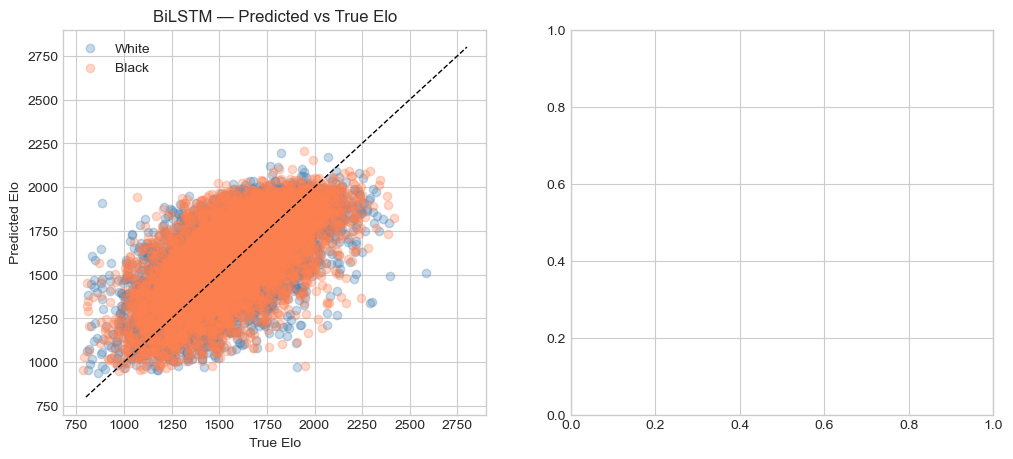

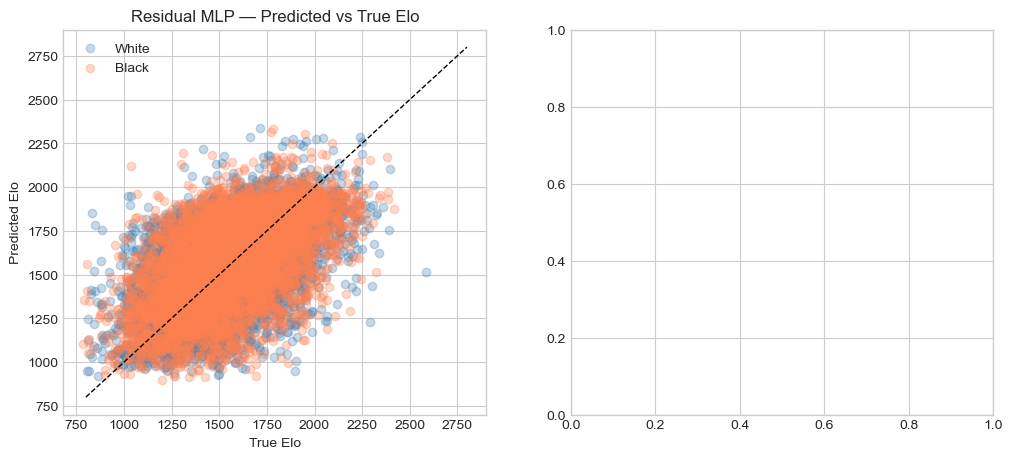

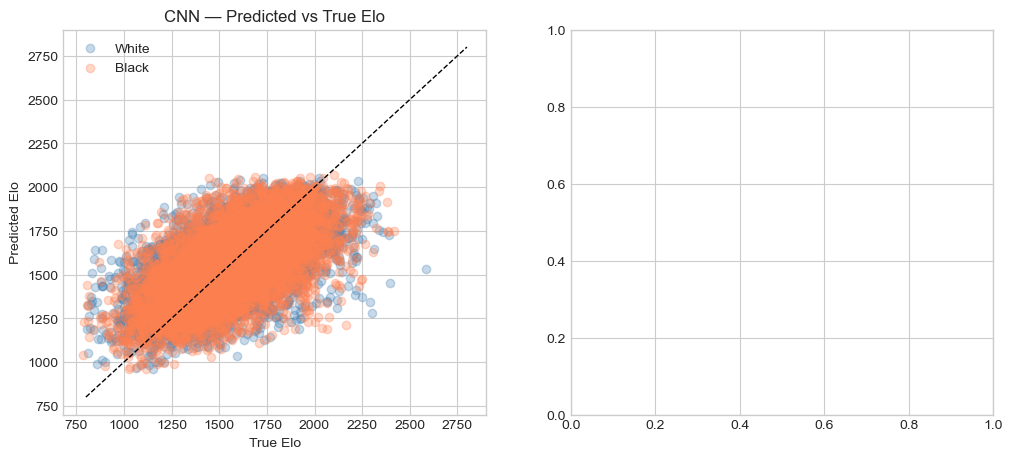

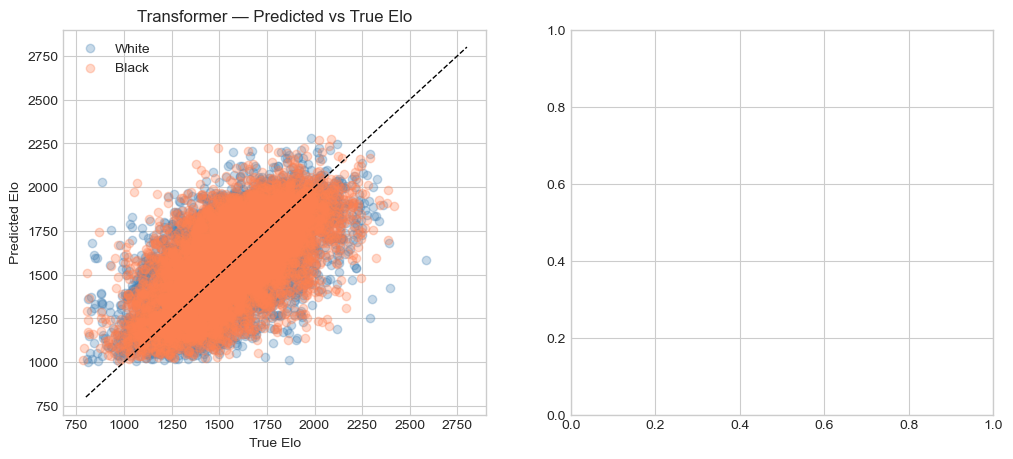

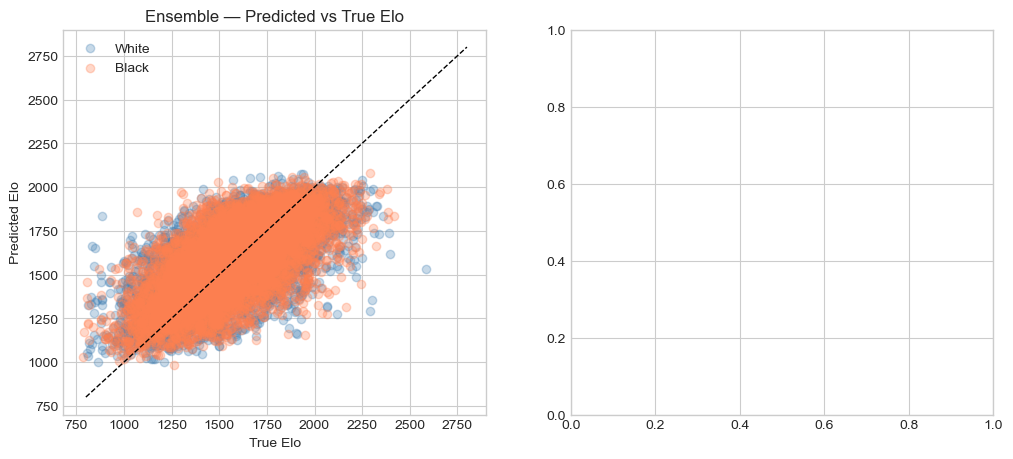

In [ ]:
#plotting test results
for name, r in results.items():
    print(f"\n{name} — Test MAE: {r['combined_mae']:.1f}")
    fig, axes = plt.subplots(1, 2, figsize=(12, 5))
    axes[0].scatter(r['w_true'], r['w_pred'], alpha=0.3, color='steelblue', label='White')
    axes[0].scatter(r['b_true'], r['b_pred'], alpha=0.3, color='coral', label='Black')
    axes[0].plot([800, 2800], [800, 2800], 'k--', lw=1)
    axes[0].set_xlabel('True Elo'); axes[0].set_ylabel('Predicted Elo')
    axes[0].set_title(f'{name} — Predicted vs True Elo')
    axes[0].legend()


# Fitting 

Games with MAE <= 67 Elo: 1241

Sharp prediction — error: 54 Elo   entropy: 2.263
Flat  prediction — error: 41 Elo   entropy: 2.821


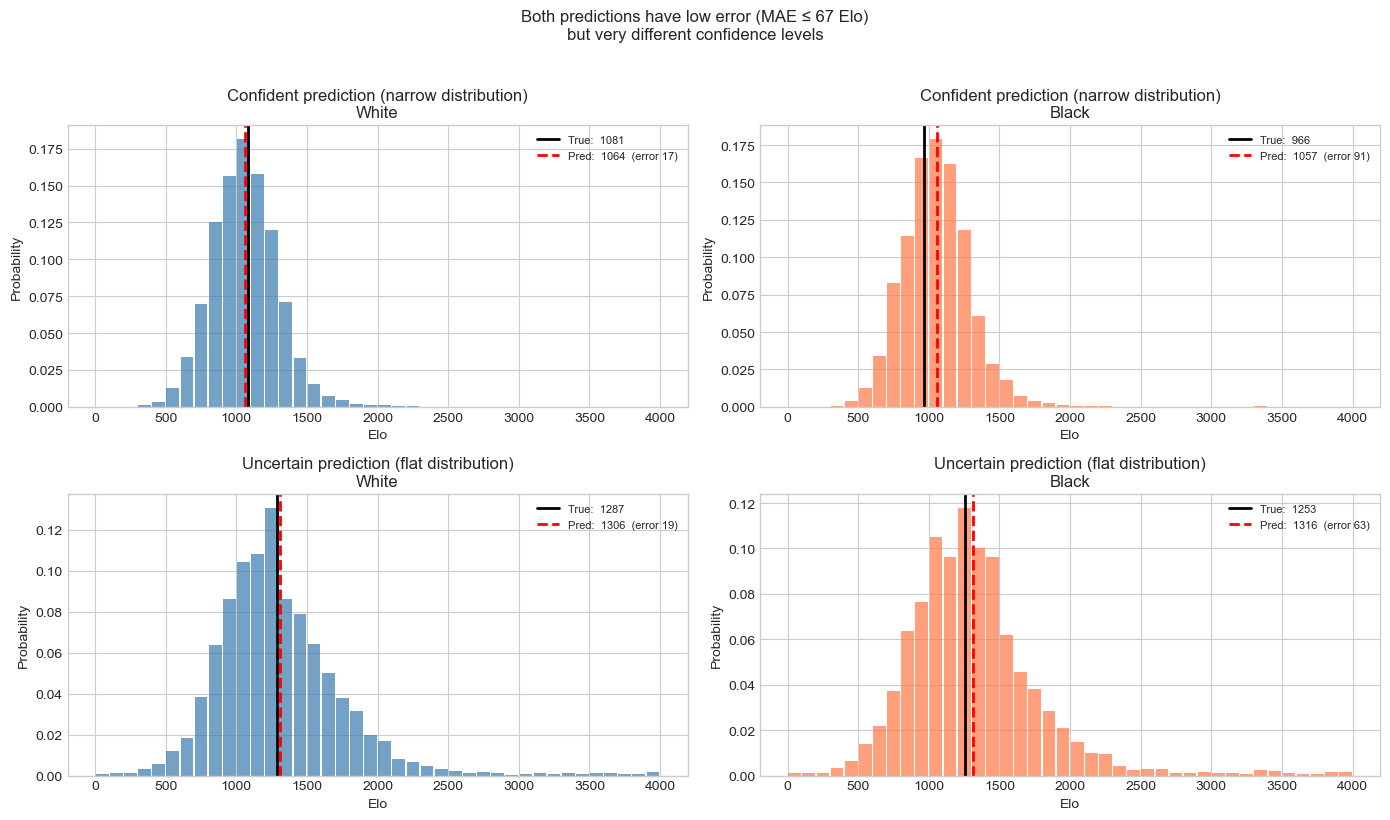

In [265]:
# ── Two low-error games: one sharp distribution, one flat ─────────────────────
import scipy.stats

model_to_check = cnn_model   # swap for any trained model

model_to_check.eval()
bins_np = BIN_CENTERS

all_w_probs, all_b_probs, all_wt, all_bt = [], [], [], []

with torch.no_grad():
    for batch in test_loader:
        batch  = {k: v.to(device) for k, v in batch.items()}
        w_out, b_out = model_to_check(batch)
        all_w_probs.append(w_out.softmax(-1).cpu().numpy())
        all_b_probs.append(b_out.softmax(-1).cpu().numpy())
        all_wt.extend(batch['elos'][:, 0].cpu().numpy())
        all_bt.extend(batch['elos'][:, 1].cpu().numpy())

w_probs = np.vstack(all_w_probs)
b_probs = np.vstack(all_b_probs)
w_true  = np.array(all_wt)
b_true  = np.array(all_bt)

w_pred = (w_probs * bins_np).sum(axis=1)
b_pred = (b_probs * bins_np).sum(axis=1)

per_game_mae = (np.abs(w_pred - w_true) + np.abs(b_pred - b_true)) / 2
avg_entropy  = (scipy.stats.entropy(w_probs, axis=1) +
                scipy.stats.entropy(b_probs, axis=1)) / 2

# only look at games where the model did well — bottom 20% of errors
error_threshold = np.percentile(per_game_mae, 20)
good_games      = np.where(per_game_mae <= error_threshold)[0]

print(f"Games with MAE <= {error_threshold:.0f} Elo: {len(good_games)}")

# among those good games, find the sharpest and flattest distribution
sharp_idx = good_games[avg_entropy[good_games].argmin()]
flat_idx  = good_games[avg_entropy[good_games].argmax()]

print(f"\nSharp prediction — error: {per_game_mae[sharp_idx]:.0f} Elo   entropy: {avg_entropy[sharp_idx]:.3f}")
print(f"Flat  prediction — error: {per_game_mae[flat_idx]:.0f} Elo   entropy: {avg_entropy[flat_idx]:.3f}")

# ── plot ──────────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(2, 2, figsize=(14, 8))

cases = [
    (sharp_idx, "Confident prediction (narrow distribution)"),
    (flat_idx,  "Uncertain prediction (flat distribution)"),
]

for row, (idx, title) in enumerate(cases):
    for col, (probs, true_elo, pred_elo_val, label, color) in enumerate([
        (w_probs[idx], w_true[idx], w_pred[idx], "White", "steelblue"),
        (b_probs[idx], b_true[idx], b_pred[idx], "Black", "coral"),
    ]):
        ax = axes[row, col]
        error   = abs(pred_elo_val - true_elo)
        entropy = scipy.stats.entropy(probs)

        ax.bar(bins_np, probs, width=90, color=color, alpha=0.75)
        ax.axvline(true_elo,     color='black', lw=2,
                   label=f'True:  {true_elo:.0f}')
        ax.axvline(pred_elo_val, color='red',   lw=2, ls='--',
                   label=f'Pred:  {pred_elo_val:.0f}  (error {error:.0f})')
        ax.set_xlabel('Elo')
        ax.set_ylabel('Probability')
        ax.set_title(f'{title}\n{label}')
        ax.legend(fontsize=8)

plt.suptitle(f'Both predictions have low error (MAE ≤ {error_threshold:.0f} Elo)\n'
             f'but very different confidence levels',
             fontsize=12, y=1.02)
plt.tight_layout()
plt.show()

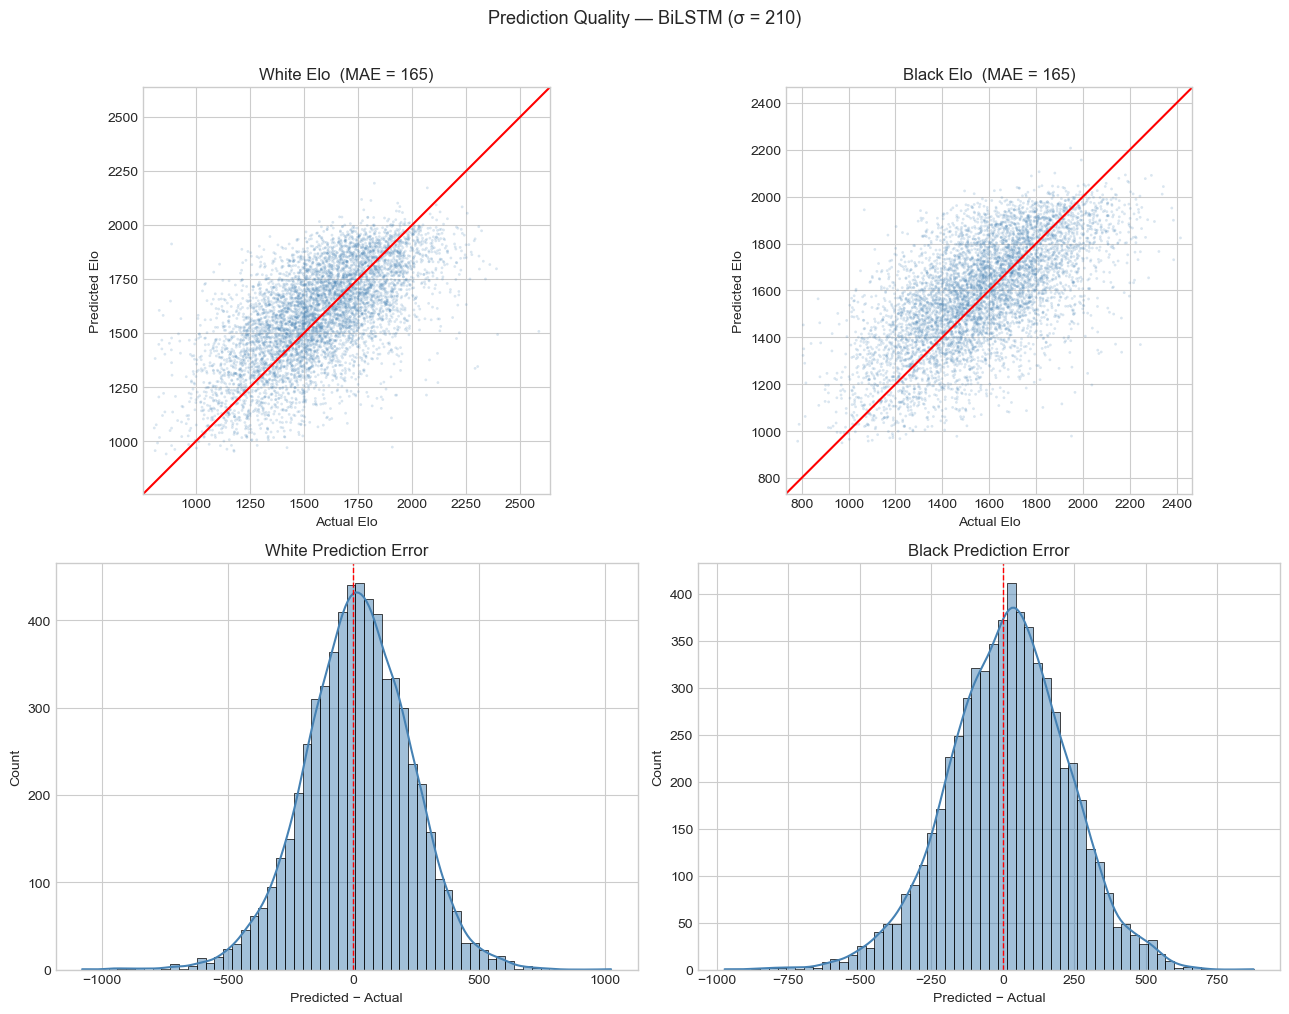

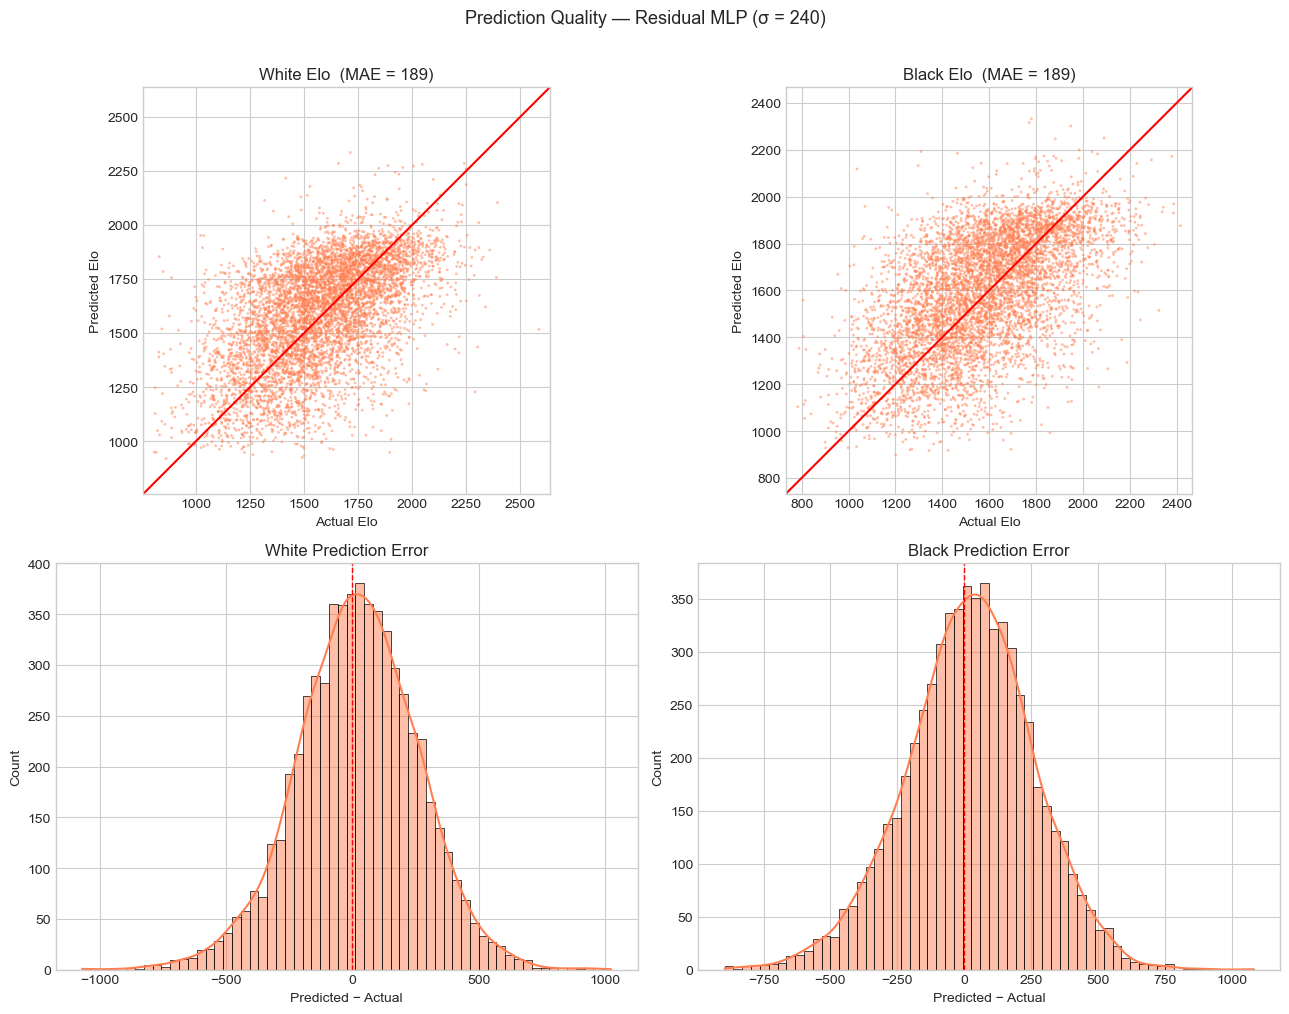

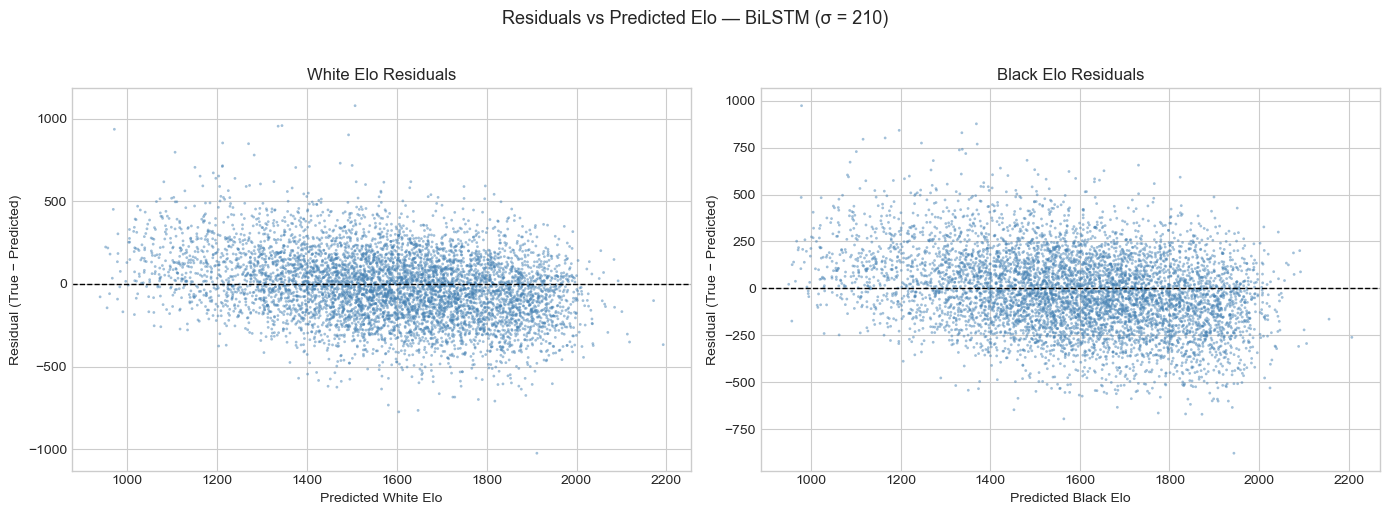

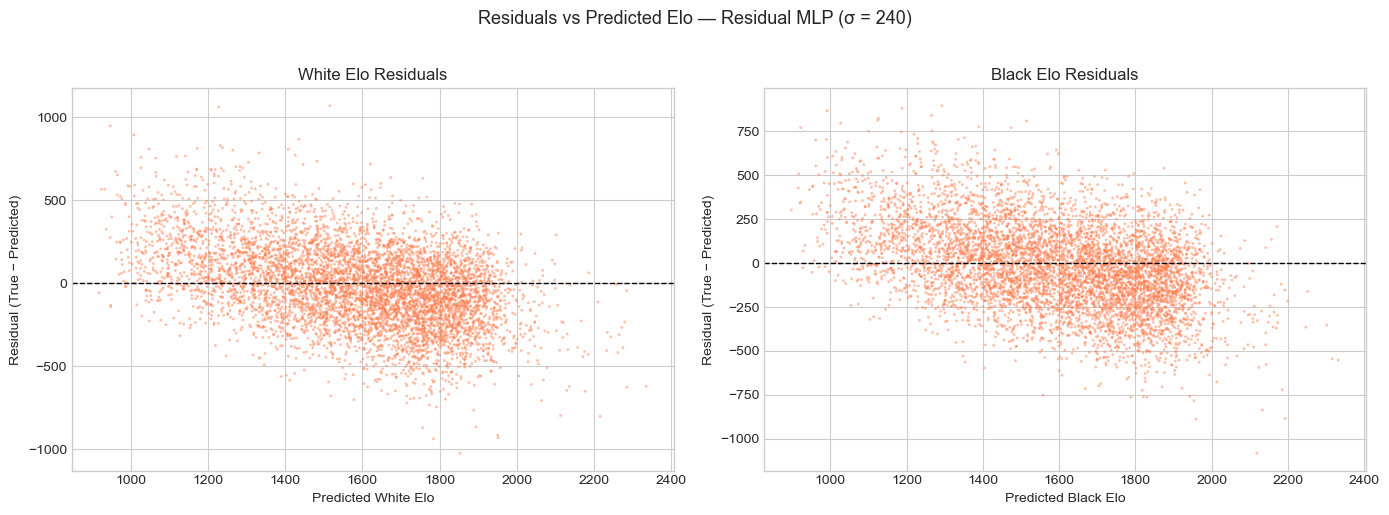

In [290]:
from sklearn.metrics import mean_absolute_error

# ── BiLSTM (best model) ───────────────────────────────────────────────────────
white_preds = results['BiLSTM']['w_pred']
black_preds = results['BiLSTM']['b_pred']
white_trues = results['BiLSTM']['w_true']
black_trues = results['BiLSTM']['b_true']
sigma_best_gauss = np.std(np.concatenate([white_preds - white_trues, black_preds - black_trues]))

fig, axes = plt.subplots(2, 2, figsize=(13, 10))
for ax, preds, trues, label in [
    (axes[0, 0], white_preds, white_trues, 'White Elo'),
    (axes[0, 1], black_preds, black_trues, 'Black Elo')]:
    lo = min(trues.min(), preds.min()) - 50
    hi = max(trues.max(), preds.max()) + 50
    ax.scatter(trues, preds, alpha=0.2, s=4, color='steelblue', edgecolors='none')
    ax.plot([lo, hi], [lo, hi], 'r-', lw=1.5)
    ax.set_xlabel('Actual Elo'); ax.set_ylabel('Predicted Elo')
    ax.set_title(f'{label}  (MAE = {mean_absolute_error(trues, preds):.0f})')
    ax.set_xlim(lo, hi); ax.set_ylim(lo, hi); ax.set_aspect('equal')

for ax, preds, trues, label in [
    (axes[1, 0], white_preds, white_trues, 'White Prediction Error'),
    (axes[1, 1], black_preds, black_trues, 'Black Prediction Error')]:
    errors = preds - trues
    sns.histplot(errors, bins=60, kde=True, ax=ax, color='steelblue')
    ax.axvline(0, color='red', lw=1, ls='--')
    ax.set_xlabel('Predicted − Actual')
    ax.set_title(label)

plt.suptitle(f'Prediction Quality — BiLSTM (σ = {sigma_best_gauss:.0f})', fontsize=13, y=1.01)
plt.tight_layout(); plt.show()

# ── Residual MLP (baseline) ───────────────────────────────────────────────────
white_preds = results['Residual MLP']['w_pred']
black_preds = results['Residual MLP']['b_pred']
white_trues = results['Residual MLP']['w_true']
black_trues = results['Residual MLP']['b_true']
sigma_worst_gauss = np.std(np.concatenate([white_preds - white_trues, black_preds - black_trues]))

fig, axes = plt.subplots(2, 2, figsize=(13, 10))
for ax, preds, trues, label in [
    (axes[0, 0], white_preds, white_trues, 'White Elo'),
    (axes[0, 1], black_preds, black_trues, 'Black Elo')]:
    lo = min(trues.min(), preds.min()) - 50
    hi = max(trues.max(), preds.max()) + 50
    ax.scatter(trues, preds, alpha=0.5, s=4, color='coral', edgecolors='none')
    ax.plot([lo, hi], [lo, hi], 'r-', lw=1.5)
    ax.set_xlabel('Actual Elo'); ax.set_ylabel('Predicted Elo')
    ax.set_title(f'{label}  (MAE = {mean_absolute_error(trues, preds):.0f})')
    ax.set_xlim(lo, hi); ax.set_ylim(lo, hi); ax.set_aspect('equal')

for ax, preds, trues, label in [
    (axes[1, 0], white_preds, white_trues, 'White Prediction Error'),
    (axes[1, 1], black_preds, black_trues, 'Black Prediction Error')]:
    errors = preds - trues
    sns.histplot(errors, bins=60, kde=True, ax=ax, color='coral')
    ax.axvline(0, color='red', lw=1, ls='--')
    ax.set_xlabel('Predicted − Actual')
    ax.set_title(label)

plt.suptitle(f'Prediction Quality — Residual MLP (σ = {sigma_worst_gauss:.0f})', fontsize=13, y=1.01)
plt.tight_layout(); plt.show()

# ── BiLSTM residuals ──────────────────────────────────────────────────────────
bilstm_model.eval()
all_w_probs, all_b_probs, all_wt, all_bt = [], [], [], []
with torch.no_grad():
    for batch in test_loader:
        batch  = {k: v.to(device) for k, v in batch.items()}
        w_out, b_out = bilstm_model(batch)
        all_w_probs.append(w_out.softmax(-1).cpu().numpy())
        all_b_probs.append(b_out.softmax(-1).cpu().numpy())
        all_wt.extend(batch['elos'][:, 0].cpu().numpy())
        all_bt.extend(batch['elos'][:, 1].cpu().numpy())

w_probs = np.vstack(all_w_probs); b_probs = np.vstack(all_b_probs)
w_true  = np.array(all_wt);       b_true  = np.array(all_bt)
w_pred  = (w_probs * BIN_CENTERS).sum(axis=1)
b_pred  = (b_probs * BIN_CENTERS).sum(axis=1)
residuals_w = w_true - w_pred
residuals_b = b_true - b_pred
sigma_best  = np.std(np.concatenate([residuals_w, residuals_b]))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].scatter(w_pred, residuals_w, alpha=0.5, s=4, color='steelblue', edgecolors='none')
axes[1].scatter(b_pred, residuals_b, alpha=0.5, s=4, color='steelblue', edgecolors='none')
for ax, xlabel in zip(axes, ['Predicted White Elo', 'Predicted Black Elo']):
    ax.axhline(0, color='black', lw=1, ls='--')
    ax.set_xlabel(xlabel); ax.set_ylabel('Residual (True − Predicted)')
axes[0].set_title('White Elo Residuals')
axes[1].set_title('Black Elo Residuals')
plt.suptitle(f'Residuals vs Predicted Elo — BiLSTM (σ = {sigma_best:.0f})', fontsize=13, y=1.02)
plt.tight_layout(); plt.show()

# ── Residual MLP residuals ────────────────────────────────────────────────────
residual_model.eval()
all_w_probs, all_b_probs, all_wt, all_bt = [], [], [], []
with torch.no_grad():
    for batch in test_loader:
        batch  = {k: v.to(device) for k, v in batch.items()}
        w_out, b_out = residual_model(batch)
        all_w_probs.append(w_out.softmax(-1).cpu().numpy())
        all_b_probs.append(b_out.softmax(-1).cpu().numpy())
        all_wt.extend(batch['elos'][:, 0].cpu().numpy())
        all_bt.extend(batch['elos'][:, 1].cpu().numpy())

w_probs = np.vstack(all_w_probs); b_probs = np.vstack(all_b_probs)
w_true  = np.array(all_wt);       b_true  = np.array(all_bt)
w_pred  = (w_probs * BIN_CENTERS).sum(axis=1)
b_pred  = (b_probs * BIN_CENTERS).sum(axis=1)
residuals_w = w_true - w_pred
residuals_b = b_true - b_pred
sigma_worst = np.std(np.concatenate([residuals_w, residuals_b]))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].scatter(w_pred, residuals_w, alpha=0.5, s=4, color='coral', edgecolors='none')
axes[1].scatter(b_pred, residuals_b, alpha=0.5, s=4, color='coral', edgecolors='none')
for ax, xlabel in zip(axes, ['Predicted White Elo', 'Predicted Black Elo']):
    ax.axhline(0, color='black', lw=1, ls='--')
    ax.set_xlabel(xlabel); ax.set_ylabel('Residual (True − Predicted)')
axes[0].set_title('White Elo Residuals')
axes[1].set_title('Black Elo Residuals')
plt.suptitle(f'Residuals vs Predicted Elo — Residual MLP (σ = {sigma_worst:.0f})', fontsize=13, y=1.02)
plt.tight_layout(); plt.show()

In [266]:
def pct_within(r, thr):
    return 100 * np.mean(
        (np.abs(r['w_pred'] - r['w_true']) < thr) &
        (np.abs(r['b_pred'] - r['b_true']) < thr)
    )

rows = []
for name, r in results.items():
    rows.append({
        'Model':        name,
        'White MAE':   f"{r['mae_white']:.1f}",
        'Black MAE':   f"{r['mae_black']:.1f}",
        'Combined MAE': f"{r['combined_mae']:.1f}",
        'Within 100':  f"{pct_within(r, 100):.1f}%",
        'Within 200':  f"{pct_within(r, 200):.1f}%",
        'Within 300':  f"{pct_within(r, 300):.1f}%",
    })

summary = pd.DataFrame(rows).set_index('Model')
print(summary.to_string())


             White MAE Black MAE Combined MAE Within 100 Within 200 Within 300
Model                                                                         
BiLSTM           164.9     165.3        165.1      24.2%      56.1%      78.8%
Residual MLP     189.4     189.4        189.4      20.0%      49.7%      72.2%
CNN              167.9     168.0        168.0      23.6%      55.4%      77.3%
Transformer      173.7     172.3        173.0      22.8%      54.1%      76.3%


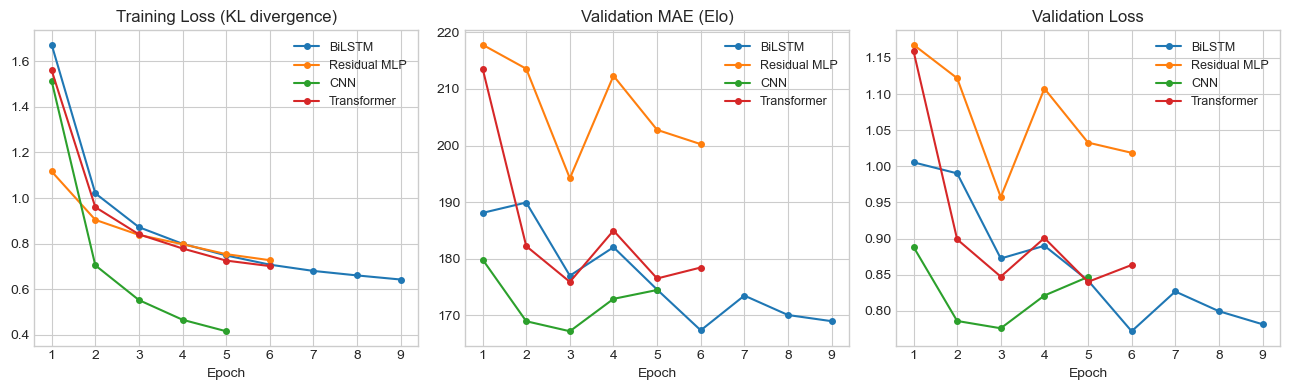

In [267]:
if histories:
    fig, axes = plt.subplots(1, 3, figsize=(13, 4))
    colors = plt.cm.tab10.colors
    for i, (name, h) in enumerate(histories.items()):
        c = colors[i % len(colors)]
        axes[0].plot([e['epoch']   for e in h], [e['loss']    for e in h],
                     '-o', label=name, color=c, markersize=4)
        axes[1].plot([e['epoch']   for e in h], [e['val_mae'] for e in h],
                     '-o', label=name, color=c, markersize=4)
        axes[2].plot([e['epoch']   for e in h], [e['val_loss'] for e in h],
                     '-o', label=name, color=c, markersize=4)
    axes[0].set_title('Training Loss (KL divergence)'); axes[0].set_xlabel('Epoch')
    axes[1].set_title('Validation MAE (Elo)');          axes[1].set_xlabel('Epoch')
    axes[2].set_title('Validation Loss');              axes[2].set_xlabel('Epoch')
    for ax in axes: ax.legend(fontsize=9)
    plt.tight_layout(); plt.show()


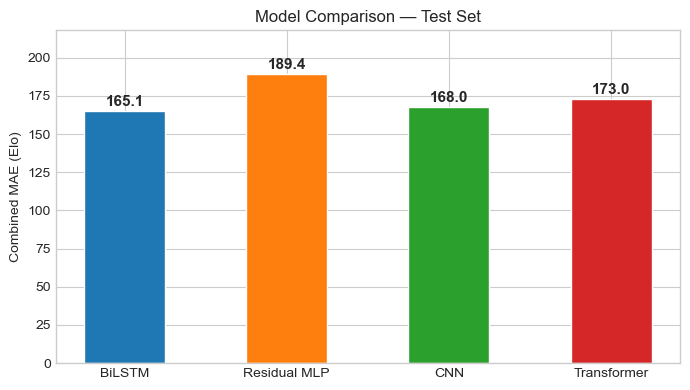

In [268]:
if results:
    names = list(results.keys())
    maes  = [results[n]['combined_mae'] for n in names]
    fig, ax = plt.subplots(figsize=(7, 4))
    bars = ax.bar(names, maes, color=plt.cm.tab10.colors[:len(names)],
                  edgecolor='white', width=0.5)
    for bar, val in zip(bars, maes):
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 1,
                f'{val:.1f}', ha='center', va='bottom', fontsize=11, fontweight='bold')
    ax.set_ylabel('Combined MAE (Elo)')
    ax.set_title('Model Comparison — Test Set')
    ax.set_ylim(0, max(maes) * 1.15)
    plt.tight_layout(); plt.show()


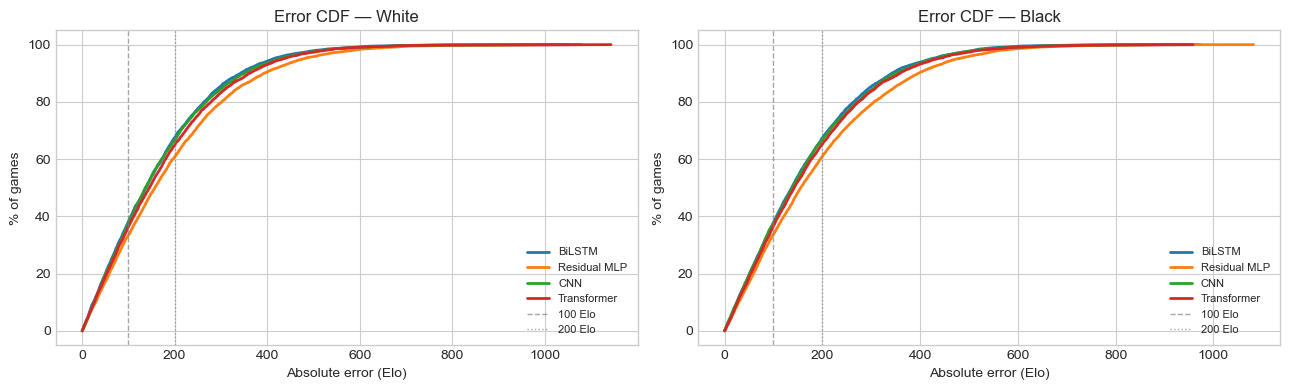

In [ ]:
if results:
    fig, axes = plt.subplots(1, 2, figsize=(13, 4))
    colors = plt.cm.tab10.colors
    for i, (name, r) in enumerate(results.items()):
        c = colors[i % len(colors)]
        for ax, pred, true, title in [
            (axes[0], r['w_pred'], r['w_true'], 'White'),
            (axes[1], r['b_pred'], r['b_true'], 'Black'),
        ]:
            errs = np.sort(np.abs(pred - true))
            ys   = np.linspace(0, 100, len(errs))
            ax.plot(errs, ys, label=name, color=c, lw=2)
    for ax, title in zip(axes, ['White', 'Black']):
        for thr, ls in [(100, '--'), (200, ':')]:
            ax.axvline(thr, color='grey', ls=ls, lw=1, alpha=0.7, label=f'{thr} Elo')
        ax.set_xlabel('Absolute error (Elo)'); ax.set_ylabel('% of games')
        ax.set_title(f'Error CDF — {title}'); ax.legend(fontsize=8) #CDF means cumulative distribution function, which shows the percentage of games that have an absolute error less than or equal to a certain value.
    plt.tight_layout(); plt.show()


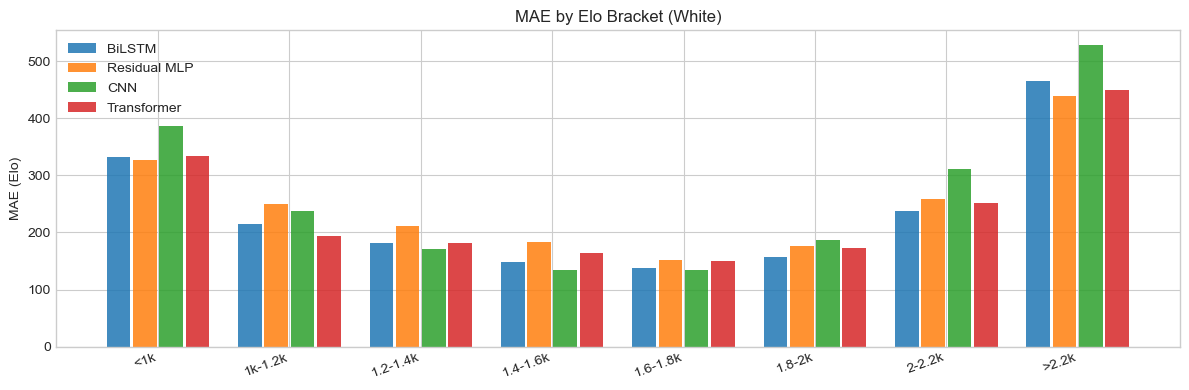

In [270]:
if results:
    edges  = [0, 1000, 1200, 1400, 1600, 1800, 2000, 2200, 4001]
    labels = ['<1k','1k-1.2k','1.2-1.4k','1.4-1.6k','1.6-1.8k','1.8-2k','2-2.2k','>2.2k']
    fig, ax = plt.subplots(figsize=(12, 4))
    x = np.arange(len(labels))
    w = 0.8 / max(len(results), 1)
    colors = plt.cm.tab10.colors
    for i, (name, r) in enumerate(results.items()):
        bracket_maes = []
        for lo, hi in zip(edges[:-1], edges[1:]):
            mask = (r['w_true'] >= lo) & (r['w_true'] < hi)
            bracket_maes.append(
                np.abs(r['w_pred'][mask] - r['w_true'][mask]).mean() if mask.sum() > 10 else np.nan
            )
        offset = (i - len(results) / 2) * w + w / 2
        ax.bar(x + offset, bracket_maes, width=w * 0.9,
               label=name, color=colors[i % len(colors)], alpha=0.85)
    ax.set_xticks(x); ax.set_xticklabels(labels, rotation=20, ha='right')
    ax.set_ylabel('MAE (Elo)'); ax.set_title('MAE by Elo Bracket (White)')
    ax.legend(); plt.tight_layout(); plt.show()


FEATURE IMPORTANCE — all models

  Computing for BiLSTM...
    Base MAE: 165.8

  Computing for Residual MLP...
    Base MAE: 185.2

  Computing for CNN...
    Base MAE: 169.3

  Computing for Transformer...
    Base MAE: 171.3

DELTA MAE  (positive = removing this hurts the model)
  Feature / Branch                         BiLSTM   Residual MLP            CNN    Transformer
  --------------------------------------------------------------------------------------------
  static: game_structure                      4.7           27.5            1.2            4.2
  static: checks                              1.4            2.5            3.1            2.5
  static: captures                            2.0            6.2            1.3            2.1
  static: castling                           -0.0            0.4           -0.2           -0.4
  static: style                               6.1           29.6            5.4           16.4
  static: engine_quality                      2.0   

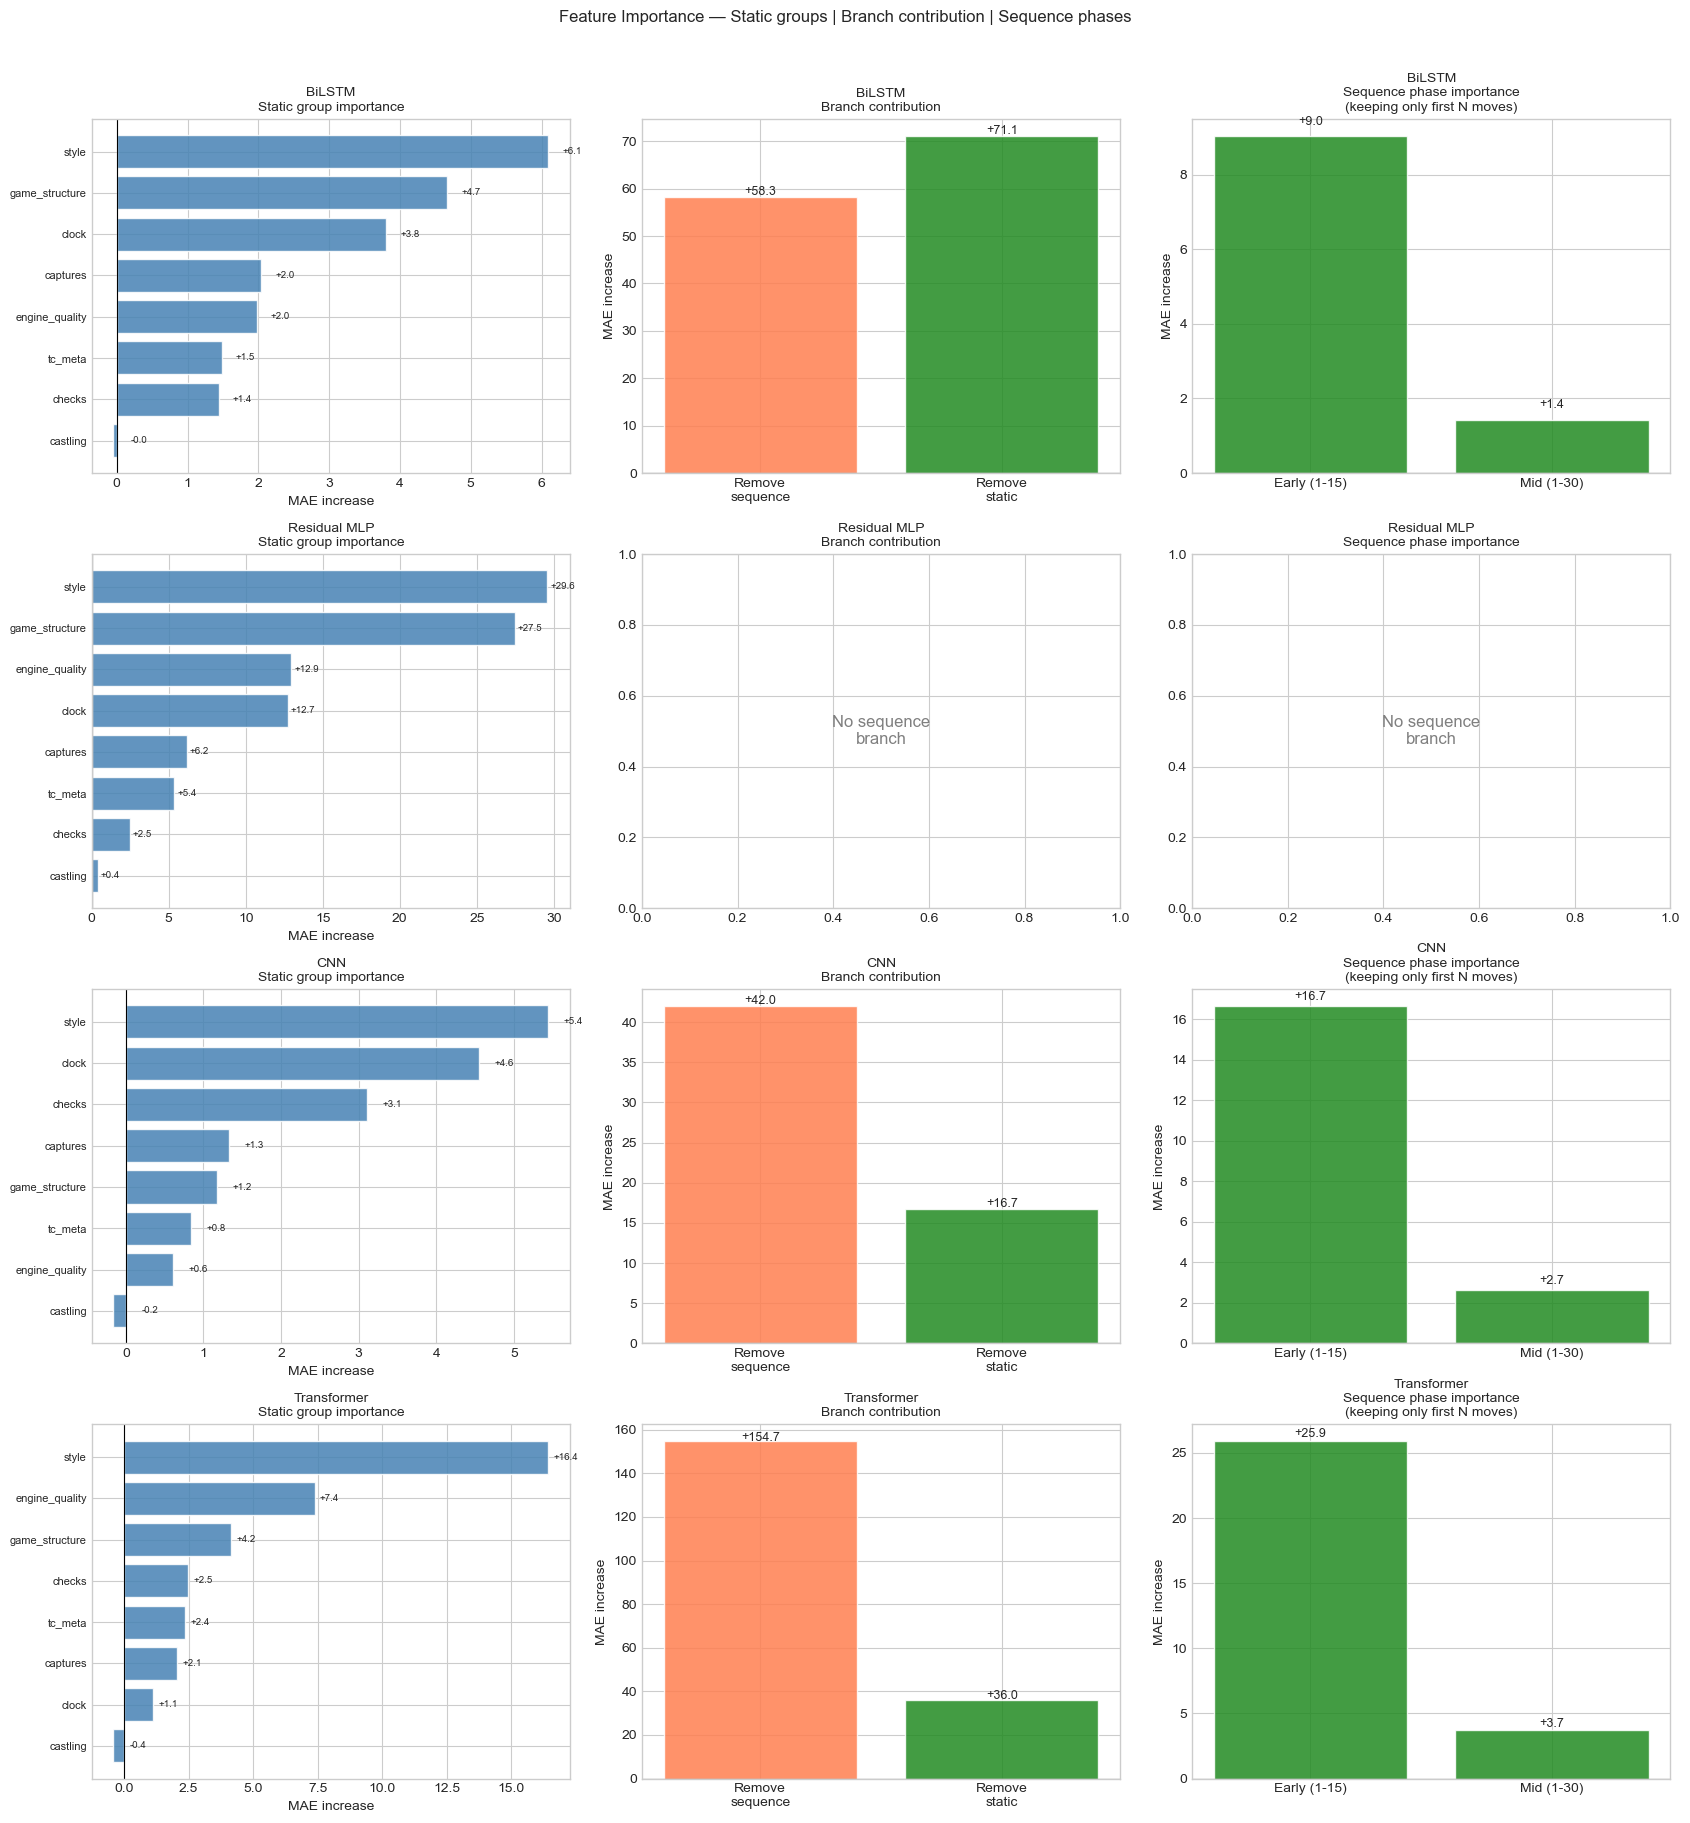


SUMMARY
-------------------------------------------------------

  BiLSTM  (base MAE = 165.8)
    Most important static group : style  (Δ=+6.1)
    Removing sequence adds      : +58.3 Elo
    Removing static adds        : +71.1 Elo
    Dominant branch             : static

  Residual MLP  (base MAE = 185.2)
    Most important static group : style  (Δ=+29.6)

  CNN  (base MAE = 169.3)
    Most important static group : style  (Δ=+5.4)
    Removing sequence adds      : +42.0 Elo
    Removing static adds        : +16.7 Elo
    Dominant branch             : sequence

  Transformer  (base MAE = 171.3)
    Most important static group : style  (Δ=+16.4)
    Removing sequence adds      : +154.7 Elo
    Removing static adds        : +36.0 Elo
    Dominant branch             : sequence


In [271]:
# ── Complete feature importance analysis ──────────────────────────────────────
# Three things in one cell:
#   1. Static vs sequence branch contribution (how much each branch matters)
#   2. Which static feature groups matter most (ablation per group)
#   3. Which part of the sequence matters most (early vs mid vs late moves)

from sklearn.metrics import mean_absolute_error

GROUP_PREFIXES = {
    'game_structure': ['total_ply', 'material_balance', 'result_encoded'],
    'checks':         ['checks_given', 'check_density'],
    'captures':       ['first_capture', 'pawn_captures', 'piece_captures', 'capture_density'],
    'castling':       ['castle_move', 'castle_side'],
    'style':          ['consec_same', 'queen_moves', 'white_territory', 'black_territory',
                       'promotions', 'en_passant', 'legal_moves'],
    'engine_quality': ['acpl', 'inaccuracy', 'mistake', 'blunder'],
    'clock':          ['w_avg_time', 'w_std_time', 'w_max_time', 'w_time_pressure',
                       'w_opening_pace', 'b_avg_time', 'b_std_time', 'b_max_time',
                       'b_time_pressure', 'b_opening_pace'],
    'tc_meta':        ['tc_base', 'tc_inc'],
}
print("=" * 65)
print("FEATURE IMPORTANCE — all models")
print("=" * 65)

bins_t = torch.tensor(BIN_CENTERS, device=device)

def run_inference(model, loader, static_mask=None, seq_cutoff=None, zero_seq=False):
    """
    General inference function with optional masking.
    static_mask : list of column indices to zero out in static features
    seq_cutoff  : only keep moves[:seq_cutoff], zero the rest
    zero_seq    : replace entire move sequence with padding
    """
    model.eval()
    all_wp, all_bp, all_wt, all_bt = [], [], [], []
    with torch.no_grad():
        for batch in loader:
            st = batch['static'].clone().to(device)
            if static_mask:
                st[:, static_mask] = 0.0

            mod_batch = {**batch, 'static': st}

            if 'moves' in batch:
                if zero_seq:
                    mod_batch['moves']  = torch.zeros_like(batch['moves'])
                    mod_batch['clocks'] = torch.zeros_like(batch['clocks'])
                    mod_batch['mask']   = torch.zeros_like(batch['mask']).bool()
                elif seq_cutoff is not None:
                    mv = batch['moves'].clone()
                    cl = batch['clocks'].clone()
                    mv[:, seq_cutoff:] = 0
                    cl[:, seq_cutoff:] = 0.0
                    mod_batch['moves']  = mv
                    mod_batch['clocks'] = cl
                    mod_batch['mask']   = (mv != 0)

            w_out, b_out = model(mod_batch)
            wp = (w_out.softmax(-1) * bins_t).sum(-1).cpu().numpy()
            bp = (b_out.softmax(-1) * bins_t).sum(-1).cpu().numpy()
            wp = np.nan_to_num(wp, nan=1600.0)
            bp = np.nan_to_num(bp, nan=1600.0)
            all_wp.extend(wp); all_bp.extend(bp)
            all_wt.extend(batch['elos'][:, 0].numpy())
            all_bt.extend(batch['elos'][:, 1].numpy())
    return (mean_absolute_error(all_wt, all_wp) +
            mean_absolute_error(all_bt, all_bp)) / 2


N_ABL    = min(2000, len(test_ds))
abl_ldr  = DataLoader(
    torch.utils.data.Subset(test_ds, range(N_ABL)),
    batch_size=BATCH_SIZE, shuffle=False, collate_fn=collate, num_workers=0)

all_models = {}
if RUN_BILSTM      and 'bilstm_model'      in dir(): all_models['BiLSTM']      = bilstm_model
if RUN_RESIDUAL    and 'residual_model'    in dir(): all_models['Residual MLP'] = residual_model
if RUN_CNN         and 'cnn_model'         in dir(): all_models['CNN']          = cnn_model
if RUN_TRANSFORMER and 'transformer_model' in dir(): all_models['Transformer']  = transformer_model

# column indices per feature group
group_col_indices = {}
for grp, prefixes in GROUP_PREFIXES.items():
    idxs = [i for i, c in enumerate(static_cols)
             if any(c.startswith(p) for p in prefixes)]
    if idxs:
        group_col_indices[grp] = idxs

# sequence phase cutoffs — early/mid/late
seq_phases = {'Early (1-15)': 15, 'Mid (1-30)': 30, 'Full sequence': None}

# ── run everything ────────────────────────────────────────────────────────────
importance = {}   # importance[model_name] = dict of label -> delta MAE

for mname, model in all_models.items():
    print(f"\n  Computing for {mname}...")
    base = run_inference(model, abl_ldr)
    deltas = {'[BASE MAE]': base}

    # static groups
    for grp, idxs in group_col_indices.items():
        deltas[f'static: {grp}'] = run_inference(model, abl_ldr, static_mask=idxs) - base

    # branch-level (sequence models only)
    if mname != 'Residual MLP':
        deltas['[remove sequence]'] = run_inference(model, abl_ldr, zero_seq=True) - base
        deltas['[remove static]']   = run_inference(model, abl_ldr,
                                          static_mask=list(range(len(static_cols)))) - base
        # sequence phases
        for label, cutoff in seq_phases.items():
            if cutoff is not None:
                delta = run_inference(model, abl_ldr, seq_cutoff=cutoff) - base
                deltas[f'seq phase: {label}'] = delta

    importance[mname] = {'base': base, 'deltas': deltas}
    print(f"    Base MAE: {base:.1f}")

# ── summary table ─────────────────────────────────────────────────────────────
print("\n" + "=" * 65)
print("DELTA MAE  (positive = removing this hurts the model)")
print("=" * 65)

all_labels  = []
for d in importance.values():
    for k in d['deltas']:
        if k != '[BASE MAE]' and k not in all_labels:
            all_labels.append(k)

mnames  = list(importance.keys())
col_w   = 15
print(f"  {'Feature / Branch':<32s}" + "".join(f"{n:>{col_w}s}" for n in mnames))
print("  " + "-" * (32 + col_w * len(mnames)))

for label in all_labels:
    row = f"  {label:<32s}"
    for mname in mnames:
        val = importance[mname]['deltas'].get(label, None)
        row += f"{val:>{col_w}.1f}" if val is not None else f"{'—':>{col_w}s}"
    print(row)

print("  " + "-" * (32 + col_w * len(mnames)))
base_row = f"  {'Base MAE':<32s}"
for mname in mnames:
    base_row += f"{importance[mname]['base']:>{col_w}.1f}"
print(base_row)

# ── plots ─────────────────────────────────────────────────────────────────────
n_models = len(importance)
fig, axes = plt.subplots(n_models, 3, figsize=(17, 4.5 * n_models))
if n_models == 1:
    axes = [axes]

colors_static = "steelblue"
colors_branch = "coral"
colors_phase  = "forestgreen"

for row_axes, (mname, data) in zip(axes, importance.items()):
    base  = data['base']
    delts = data['deltas']

    # ── left: static feature groups ──────────────────────────────────────────
    ax = row_axes[0]
    static_items = [(k.replace('static: ', ''), v)
                    for k, v in delts.items() if k.startswith('static:')]
    static_items.sort(key=lambda x: -x[1])
    if static_items:
        labels, vals = zip(*static_items)
        ax.barh(range(len(labels)), vals, color=colors_static, alpha=0.85, edgecolor='white')
        ax.set_yticks(range(len(labels)))
        ax.set_yticklabels(labels, fontsize=8)
        ax.axvline(0, color='black', lw=0.8)
        ax.invert_yaxis()
        ax.set_xlabel('MAE increase')
        ax.set_title(f'{mname}\nStatic group importance', fontsize=10)
        for i, v in enumerate(vals):
            ax.text(max(v + 0.2, 0.2), i, f'{v:+.1f}', va='center', fontsize=7)

    # ── middle: branch contribution ───────────────────────────────────────────
    ax = row_axes[1]
    if mname != 'Residual MLP':
        branch_labels = ['Remove\nsequence', 'Remove\nstatic']
        branch_vals   = [delts.get('[remove sequence]', 0),
                         delts.get('[remove static]', 0)]
        bar_colors    = [colors_branch, colors_phase]
        bars = ax.bar(branch_labels, branch_vals, color=bar_colors, alpha=0.85, edgecolor='white')
        ax.axhline(0, color='black', lw=0.8)
        ax.set_ylabel('MAE increase')
        ax.set_title(f'{mname}\nBranch contribution', fontsize=10)
        for bar, v in zip(bars, branch_vals):
            ax.text(bar.get_x() + bar.get_width()/2, max(v + 0.3, 0.3),
                    f'{v:+.1f}', ha='center', fontsize=9)
    else:
        ax.text(0.5, 0.5, 'No sequence\nbranch', ha='center', va='center',
                transform=ax.transAxes, fontsize=12, color='gray')
        ax.set_title(f'{mname}\nBranch contribution', fontsize=10)

    # ── right: sequence phase importance ─────────────────────────────────────
    ax = row_axes[2]
    if mname != 'Residual MLP':
        phase_items = [(k.replace('seq phase: ', ''), v)
                       for k, v in delts.items() if k.startswith('seq phase:')]
        if phase_items:
            p_labels, p_vals = zip(*phase_items)
            ax.bar(p_labels, p_vals, color=colors_phase, alpha=0.85, edgecolor='white')
            ax.axhline(0, color='black', lw=0.8)
            ax.set_ylabel('MAE increase')
            ax.set_title(f'{mname}\nSequence phase importance\n(keeping only first N moves)', fontsize=10)
            for i, (pl, v) in enumerate(zip(p_labels, p_vals)):
                ax.text(i, max(v + 0.3, 0.3), f'{v:+.1f}', ha='center', fontsize=9)
    else:
        ax.text(0.5, 0.5, 'No sequence\nbranch', ha='center', va='center',
                transform=ax.transAxes, fontsize=12, color='gray')
        ax.set_title(f'{mname}\nSequence phase importance', fontsize=10)

plt.suptitle('Feature Importance — Static groups | Branch contribution | Sequence phases',
             fontsize=12, y=1.01)
plt.tight_layout()
plt.show()

# ── plain English summary ─────────────────────────────────────────────────────
print("\nSUMMARY")
print("-" * 55)
for mname, data in importance.items():
    d = data['deltas']
    top_static = max(
        [(k.replace('static: ', ''), v) for k, v in d.items() if k.startswith('static:')],
        key=lambda x: x[1], default=('none', 0))
    print(f"\n  {mname}  (base MAE = {data['base']:.1f})")
    print(f"    Most important static group : {top_static[0]}  (Δ={top_static[1]:+.1f})")
    if mname != 'Residual MLP':
        seq_val  = d.get('[remove sequence]', 0)
        stat_val = d.get('[remove static]',   0)
        dominant = "sequence" if seq_val > stat_val else "static"
        print(f"    Removing sequence adds      : {seq_val:+.1f} Elo")
        print(f"    Removing static adds        : {stat_val:+.1f} Elo")
        print(f"    Dominant branch             : {dominant}")



#save fig as svg
fig.savefig('images/feature_importance.svg', format='svg')

INDIVIDUAL STATIC FEATURE IMPORTANCE — top 15 per model

  Computing for BiLSTM...

  Computing for Residual MLP...

  Computing for CNN...

  Computing for Transformer...

  BiLSTM  (base MAE = 165.8)
  Rank   Feature                                   Delta MAE
  ----------------------------------------------------------
  1      total_ply_count                               +3.31  ██████
  2      b_avg_time_norm                               +2.95  █████
  3      w_avg_time_norm                               +2.09  ████
  4      material_balance_end                          +2.08  ████
  5      capture_density                               +1.99  ███
  6      tc_inc                                        +1.48  ██
  7      consec_same_piece_white                       +1.32  ██
  8      blunder_density_black                         +0.75  █
  9      check_density_white                           +0.70  █
  10     mistake_count_white                           +0.56  █
  11     black_te

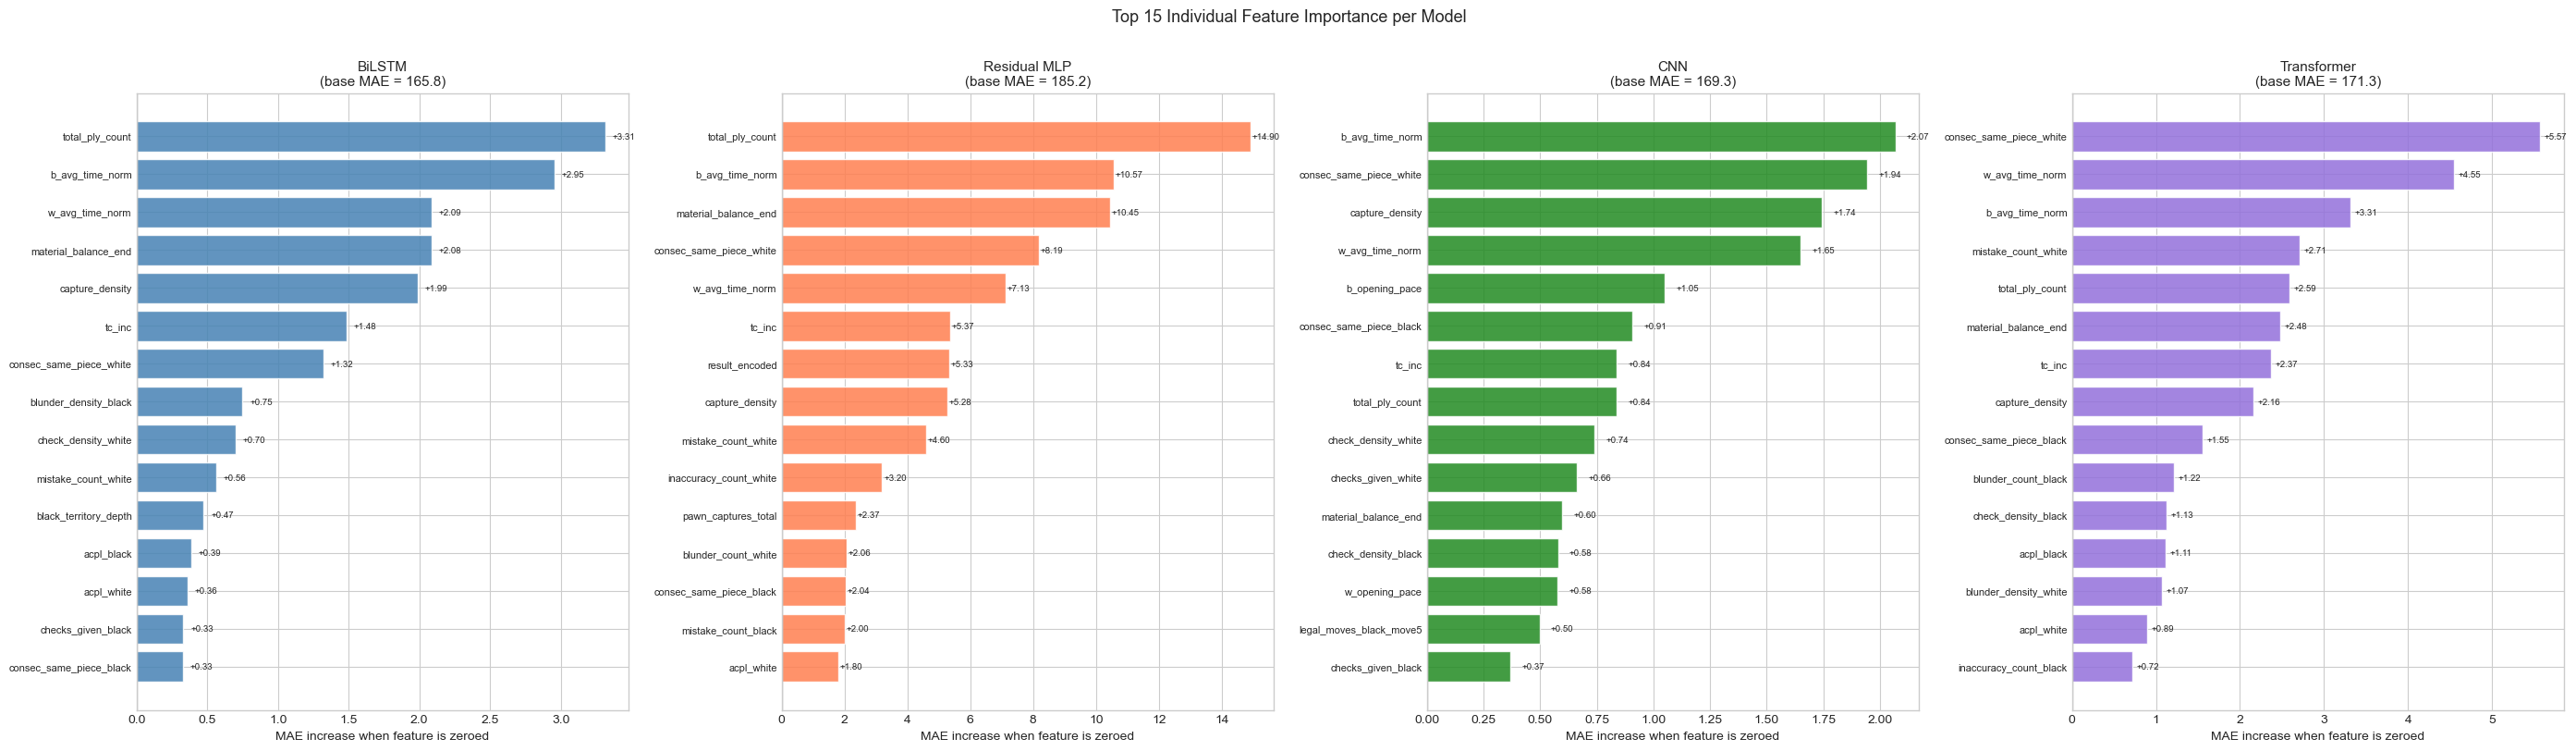

In [272]:
# ── Individual static feature importance ──────────────────────────────────────
print("=" * 75)
print("INDIVIDUAL STATIC FEATURE IMPORTANCE — top 15 per model")
print("=" * 75)

individual_importance = {}

for mname, model in all_models.items():
    print(f"\n  Computing for {mname}...")
    base = run_inference(model, abl_ldr)
    feature_deltas = {}
    for i, col_name in enumerate(static_cols):
        delta = run_inference(model, abl_ldr, static_mask=[i]) - base
        feature_deltas[col_name] = delta
    individual_importance[mname] = {'base': base, 'deltas': feature_deltas}

# ── print ranking per model ───────────────────────────────────────────────────
for mname, data in individual_importance.items():
    print(f"\n  {mname}  (base MAE = {data['base']:.1f})")
    print(f"  {'Rank':<6} {'Feature':<40} {'Delta MAE':>10}")
    print("  " + "-" * 58)
    ranked = sorted(data['deltas'].items(), key=lambda x: -x[1])
    for rank, (fname, delta) in enumerate(ranked[:15], 1):
        bar = "█" * max(0, int(delta * 2))
        print(f"  {rank:<6} {fname:<40} {delta:>+10.2f}  {bar}")

# ── side by side plot ─────────────────────────────────────────────────────────
n_models = len(individual_importance)
fig, axes = plt.subplots(1, n_models, figsize=(7 * n_models, 8), sharey=False)
if n_models == 1:
    axes = [axes]

model_colors = ['steelblue', 'coral', 'forestgreen', 'mediumpurple']

for ax, (mname, data), color in zip(axes, individual_importance.items(), model_colors):
    ranked = sorted(data['deltas'].items(), key=lambda x: -x[1])[:15]
    names, vals = zip(*ranked)
    y_pos = range(len(names))
    ax.barh(y_pos, vals, color=color, alpha=0.85, edgecolor='white')
    ax.set_yticks(y_pos)
    ax.set_yticklabels(names, fontsize=8)
    ax.axvline(0, color='black', lw=0.8)
    ax.invert_yaxis()
    ax.set_xlabel('MAE increase when feature is zeroed')
    ax.set_title(f'{mname}\n(base MAE = {data["base"]:.1f})', fontsize=11)
    for i, v in enumerate(vals):
        ax.text(max(v + 0.05, 0.05), i, f'{v:+.2f}', va='center', fontsize=7)

plt.suptitle('Top 15 Individual Feature Importance per Model', fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

In [273]:
#save fig as SVG for vector graphics editing
fig.savefig('images/feature_importance_individual.svg', format='svg')

## 7 · Ensemble

When multiple models are trained, we average their **predicted distributions**
(not just the point estimates). Because each model's errors are partially independent,
ensemble averaging typically improves both accuracy and calibration.


In [274]:
if len(results) > 1:
    ref = next(iter(results.values()))
    w_avg = np.mean([r['w_probs'] for r in results.values()], axis=0)
    b_avg = np.mean([r['b_probs'] for r in results.values()], axis=0)

    w_ens = (w_avg * BIN_CENTERS).sum(axis=1)
    b_ens = (b_avg * BIN_CENTERS).sum(axis=1)
    mae_w = float(np.abs(w_ens - ref['w_true']).mean())
    mae_b = float(np.abs(b_ens - ref['b_true']).mean())
    combined = (mae_w + mae_b) / 2

    results['Ensemble'] = {
        'mae_white': mae_w, 'mae_black': mae_b, 'combined_mae': combined,
        'w_pred': w_ens, 'b_pred': b_ens,
        'w_true': ref['w_true'], 'b_true': ref['b_true'],
        'w_probs': w_avg, 'b_probs': b_avg,
    }
    print(f'Ensemble combined MAE: {combined:.1f}  (White {mae_w:.1f}, Black {mae_b:.1f})')
else:
    print('Need at least 2 models for an ensemble.')


Ensemble combined MAE: 158.5  (White 158.9, Black 158.0)


In [275]:
rows = []
for name, r in results.items():
    rows.append({
        'Model':        name,
        'Combined MAE': f"{r['combined_mae']:.1f}",
        'Within 100':  f"{pct_within(r, 100):.1f}%",
        'Within 200':  f"{pct_within(r, 200):.1f}%",
        'Within 300':  f"{pct_within(r, 300):.1f}%",
    })
final_df = pd.DataFrame(rows).set_index('Model')
best = min((n for n in results if n != 'Ensemble'), key=lambda n: results[n]['combined_mae'],
           default=None)
print('=' * 50)
print(final_df.to_string())
print('=' * 50)
if best:
    print(f'Best single model: {best}  (MAE = {results[best]["combined_mae"]:.1f})')


             Combined MAE Within 100 Within 200 Within 300
Model                                                     
BiLSTM              165.1      24.2%      56.1%      78.8%
Residual MLP        189.4      20.0%      49.7%      72.2%
CNN                 168.0      23.6%      55.4%      77.3%
Transformer         173.0      22.8%      54.1%      76.3%
Ensemble            158.5      25.2%      57.8%      80.6%
Best single model: BiLSTM  (MAE = 165.1)


## 8 · Single Game Demo

Paste any PGN string below and run the cell to predict both players' Elo ratings
using every trained model.


In [276]:
DEMO_PGN = (
    """1. e4 d5 2. exd5 Qxd5 3. Nc3 Qa5 4. d4 c6 5. Nf3 Nf6 6. Bc4 Bg4 7. O-O e6
    8. Bd2 Qc7 9. h3 Bf5 10. Qe2 Bd6 11. a3 O-O 12. Bg5 Nbd7 13. Rfe1 h6
    14. Bxf6 Nxf6 15. Ne5 Rfe8 16. Bd3 Bxd3 17. Qxd3 Nd5 18. Nxd5 cxd5
    19. Re3 Rac8 20. c3 Bxe5 21. Rxe5 f6 22. Re3 Qb6 23. Re2 Qd6 24. Rae1 e5
    25. dxe5 fxe5 26. Qg3 Qb6 27. Rxe5 Rxe5 28. Qxe5 Qxb2 29. Qe6+ Kh7
    30. Qxc8 Qxa3 31. Qf5+ Kh8 32. Re8+ Qf8 33. Rxf8# 1-0 """
)

def predict_game(pgn, model, model_name):
    # Extract features for a single game
    clean_pgn = ' '.join(pgn.split())
    feat   = cff.extract_features(clean_pgn, '*')
    clk    = clock_features(clean_pgn, 600)
    row    = {**feat, **clk, 'tc_base': 600, 'tc_inc': 0}
    static = np.array([row.get(c, 0.0) for c in static_cols], dtype=np.float32)
    static = np.nan_to_num(static, nan=0.0)   # ← add this line
    static = scaler.transform(static.reshape(1, -1))
    static_t = torch.tensor(static, dtype=torch.float32, device=device)
    # n_nan = sum(1 for v in row.values() if isinstance(v, float) and np.isnan(v))
    # print(f'  {model_name}: {n_nan} NaN features out of {len(row)}')
    batch = {'static': static_t,
             'w_dist': torch.zeros(1, N_BINS, device=device),
             'b_dist': torch.zeros(1, N_BINS, device=device),
             'elos':   torch.zeros(1, 2,      device=device)}

    if need_seq:
        moves, clocks_raw = tokenise(pgn)
        ids  = [encode_move(m) for m in moves[:MAX_SEQ_LEN]]
        n    = len(ids)
        nrm  = [min(max(c/600, 0.), 2.) for c in clocks_raw[:n]] + [0.5]*(n - len(clocks_raw[:n]))
        batch['moves']  = torch.tensor(ids, dtype=torch.long,    device=device).unsqueeze(0)
        batch['clocks'] = torch.tensor(nrm, dtype=torch.float32, device=device).unsqueeze(0)
        batch['mask']   = (batch['moves'] != 0)

    model.eval()
    bins = torch.tensor(BIN_CENTERS, device=device)
    with torch.no_grad():
        w_out, b_out = model(batch)
    w_elo = float((w_out.softmax(-1) * bins).sum())
    b_elo = float((b_out.softmax(-1) * bins).sum())
    return w_elo, b_elo


print(f"{'Model':<18}  {'White Elo':>10}  {'Black Elo':>10}")
print('-' * 44)
trained = {}
if RUN_BILSTM      and 'bilstm_model'      in dir(): trained['BiLSTM']      = bilstm_model
if RUN_RESIDUAL    and 'residual_model'    in dir(): trained['Residual MLP'] = residual_model
if RUN_CNN         and 'cnn_model'         in dir(): trained['CNN']          = cnn_model
if RUN_TRANSFORMER and 'transformer_model' in dir(): trained['Transformer']  = transformer_model
for name, model in trained.items():
    w, b = predict_game(DEMO_PGN, model, name)
    print(f'  {name:<16}  {w:>10.0f}  {b:>10.0f}')


Model                White Elo   Black Elo
--------------------------------------------
  BiLSTM                  1811        1801
  Residual MLP            1796        1775
  CNN                     1889        1897
  Transformer             1777        1776


In [277]:
# # ...existing code...
# import subprocess, datetime, sys, os

# nb_path  = os.path.abspath('chess_elo_final.ipynb')
# out_dir  = os.path.abspath('output_files')
# os.makedirs(out_dir, exist_ok=True)
# ts       = datetime.datetime.now().strftime('%Y%m%d_%H%M%S')
# out_html = os.path.join(out_dir, f'chess_elo_final_{MAX_GAMES:.0e}_{ts}.html')

# try:
#     # Use sys.executable to ensure we use the jupyter installed in the current python env
#     subprocess.run([sys.executable, '-m', 'jupyter', 'nbconvert', '--to', 'html', '--no-input',
#                     '--output', out_html, nb_path], check=True, capture_output=True, text=True)
#     print(f'Exported: {out_html}')
# except subprocess.CalledProcessError as e:
#     print("Failed to export notebook. Jupyter Error:")
#     print(e.stderr)
# # ...existing code...